In [1]:
import requests
from requests.auth import HTTPBasicAuth
from pprint import pprint

client_id = "5gn8smp-fge8g4aat-yev2p55-s1cfbwgp1s"
client_secret = "bRoq%XJK=ud8j1EFF+lNb85iDTkX07"

url_competitions = "https://apirest.wyscout.com/v3/competitions?areaId=ITA"

response = requests.get(
    url_competitions,
    auth=HTTPBasicAuth(client_id, client_secret))
if response.ok:
  competitions = response.json()['competitions']


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
squad_list_url = "https://apirest.wyscout.com/v3/competitions/{wyId}/teams"
players_url = "https://apirest.wyscout.com/v3/competitions/{wyId}/players"
players_career_url = "https://apirest.wyscout.com/v3/players/{wyId}/career"
seasons_url = "https://apirest.wyscout.com/v3/seasons/{wyId}"
players_by_team_url = "https://apirest.wyscout.com/v3/teams/{team_wyId}/squad"
player_anagrafica_url = "https://apirest.wyscout.com/v3/players/{wyId}"
advancedStats_url = "https://apirest.wyscout.com/v3/players/{wyId}/advancedstats"
player_match_advanced_stats_url = 'https://apirest.wyscout.com/v3/players/{wyId}/matches/{matchWyId}/advancedstats'
players_match_url = 'https://apirest.wyscout.com/v3/players/{wyId}/matches'
seasons_matches_url= 'https://apirest.wyscout.com/v3/seasons/{wyId}/matches'


In [ ]:
known_competition_ids = {
    'Serie A': 524,
    'Serie B': 527,
    'Serie C': 520,
    'Campionato Primavera 1': 516
}

teams_by_competition_direct = {}

for competition_name, wy_id in known_competition_ids.items():
    current_squad_list_url = squad_list_url.format(wyId=wy_id)

    print(f"Fetching teams for {competition_name} (wyId: {wy_id})")

    response = requests.get(
        current_squad_list_url,
        auth=HTTPBasicAuth(client_id, client_secret)
    )

    if response.ok:
        teams_data = response.json().get('teams')
        if teams_data:
            teams_by_competition_direct[competition_name] = teams_data
            print(f"Successfully fetched {len(teams_data)} teams for {competition_name}")
        else:
            print(f"No 'teams' key found in response for {competition_name}")
    else:
        print(f"Failed to fetch teams for {competition_name}: {response.status_code} - {response.text}")


Fetching teams for Serie A (wyId: 524)
Successfully fetched 20 teams for Serie A
Fetching teams for Serie B (wyId: 527)
Successfully fetched 20 teams for Serie B
Fetching teams for Serie C (wyId: 520)
Successfully fetched 60 teams for Serie C
Fetching teams for Campionato Primavera 1 (wyId: 516)
Successfully fetched 20 teams for Campionato Primavera 1


# FUNZIONI

In [ ]:
team_id_to_name_map = {}
for competition_name, teams_list in teams_by_competition_direct.items():
    for team in teams_list:
        team_id_to_name_map[team.get('wyId')] = team.get('name')


FUNZIONE CHE FORNISCE CARRIERA ALL'INTERNO DEI CAMPIONATI CONOSCIUTI SAPENDO WYID


In [ ]:
def give_me_filtered_career(player_wyId):
    # Initialize selected_player_info with generic details
    selected_player_info = {
        'name': f"Player with WyId {player_wyId} (details unknown)",
        'wyId': player_wyId,
        'team_name': 'Unknown Team',
        'birth_date': 'Unknown'
    }

    # 3. Formulate the career data URL
    career_url = players_career_url.format(wyId=player_wyId)

    # 4. Make an API request to this URL
    response = requests.get(
        career_url,
        auth=HTTPBasicAuth(client_id, client_secret)
    )

    # 5. Check if the response is successful
    if not response.ok:
        print(f"Failed to fetch career data for {selected_player_info['name']}: {response.status_code} - {response.text}")
        return

    # 6. Extract the 'career' data from the JSON response
    career_data = response.json().get('career')
    if not career_data:
        print(f"No career data found for {selected_player_info['name']}")
        return

    # 7. Filter this career_data to include only entries where the competitionId is present in known_competition_ids
    known_competition_id_values = list(known_competition_ids.values())
    filtered_career_data = [
        entry for entry in career_data
        if entry.get('competitionId') in known_competition_id_values
    ]

    # 8. If filtered_career_data is empty after filtering, print a message and return
    if not filtered_career_data:
        print(f"Nessun dato di carriera trovato per {selected_player_info['name']} nelle competizioni conosciute.")
        return

    # 9. Create a set of unique seasonId's from the filtered_career_data
    unique_season_ids = set()
    for entry in filtered_career_data:
        unique_season_ids.add(entry.get('seasonId'))

    # 10. Initialize an empty dictionary season_id_to_name_map
    season_id_to_name_map = {}
    print("Fetching season details...")
    # 11. For each unique seasonId, make an API request
    for season_id in unique_season_ids:
        if season_id:
            current_season_url = seasons_url.format(wyId=season_id)
            season_response = requests.get(
                current_season_url,
                auth=HTTPBasicAuth(client_id, client_secret)
            )
            if season_response.ok:
                season_data = season_response.json()
                season_name = season_data.get('name', f'Unknown Season ({season_id})')
                season_id_to_name_map[season_id] = season_name
            else:
                print(f"  Failed to fetch season {season_id}: {season_response.status_code} - {season_response.text}")
    print("Season details fetched.")

    # 13. Create a competition_id_to_name_map
    competition_id_to_name_map = {v: k for k, v in known_competition_ids.items()}

    print(f"\n--- Carriera dettagliata per {selected_player_info['name']} ---")
    print(f"Data di Nascita: {selected_player_info['birth_date']}")
    # 14. Iterate through each entry in filtered_career_data
    for entry in filtered_career_data:
        competition_id = entry.get('competitionId')
        team_id = entry.get('teamId')
        season_id = entry.get('seasonId')

        # 16. Use maps to get corresponding names
        competition_name = competition_id_to_name_map.get(competition_id, 'Unknown Competition')
        team_name = team_id_to_name_map.get(team_id, 'Unknown Team')
        season_name = season_id_to_name_map.get(season_id, f'Unknown Season ({season_id})')

        # 17. Print the detailed career entry information
        print(f"\nPlayer: {selected_player_info['name']} (WyId: {selected_player_info['wyId']})")
        print(f"  Competition: {competition_name} (ID: {competition_id})")
        print(f"  Team: {team_name} (ID: {team_id})")
        print(f"  Season: {season_name} (ID: {season_id})")
        print(f"  Appearances: {entry.get('appearances', 0)}")
        print(f"  Goals: {entry.get('goal', 0)}")
        print(f"  Minutes Played: {entry.get('minutesPlayed', 0)}")
        print(f"  Yellow Cards: {entry.get('yellowCard', 0)}")
        print(f"  Red Cards: {entry.get('redCards', 0)}")


FUNZIONE PER TROVARE LA ROSA COMPLETA DI UNQ SQUADRA CON TUTTI I WYID

In [ ]:
def give_me_player_from_squad(team_wyId):
    team_players = []
    page = 1
    page_count = None

    print(f"Fetching players for team WyId: {team_wyId}")

    while page_count is None or page <= page_count:
        current_players_url = f"{players_by_team_url.format(team_wyId=team_wyId)}?page={page}"
        response = requests.get(
            current_players_url,
            auth=HTTPBasicAuth(client_id, client_secret)
        )

        if response.ok:
            data = response.json()
            players_data = data.get('squad') # Changed from 'players' to 'squad' based on common Wyscout API patterns for team squads

            if players_data:
                for player in players_data:
                    full_name = f"{player.get('firstName', '')} {player.get('lastName', '')}".strip()
                    team_players.append({'name': full_name, 'wyId': player.get('wyId')})
            else:
                print(f"Warning: 'squad' key not found or empty in response for team {team_wyId} (page {page}). Full response:")
                pprint(data)

            if page_count is None:
                page_count = data.get('pageCount')
                if page_count is None: # If pageCount is not provided, assume single page
                    page_count = 1

            if page >= page_count:
                break
            page += 1
        else:
            print(f"Failed to fetch players for team {team_wyId} (page {page}): {response.status_code} - {response.text}")
            break

    print(f"Successfully fetched {len(team_players)} players for team WyId: {team_wyId}")
    return team_players


# give_me_player_from_squad(63044)


FUNZIONE PER IDENTIFICARE ANAGRAFICA GIOCATORE SAPENDO WYID

In [ ]:

def give_me_player_anagrafica_from_wyId(player_wyId):
    player_details_url_formatted = player_anagrafica_url.format(wyId=player_wyId)

    response = requests.get(
        player_details_url_formatted,
        auth=HTTPBasicAuth(client_id, client_secret)
    )

    if response.ok:
        player_data = response.json()

        # Get team name from the global map or default to 'Unknown Team'
        current_team_id = player_data.get('currentTeamId')
        current_team_name = team_id_to_name_map.get(current_team_id, 'Unknown Team')

        player_anagrafica = {
            'shortName': player_data.get('shortName', 'N/A'),
            'birthDate': player_data.get('birthDate', 'N/A'),
            'currentTeam': current_team_name,
            'role': player_data.get('role', {}).get('name', 'N/A')
        }
        return player_anagrafica
    else:
        print(f"Failed to fetch anagrafica for WyId {player_wyId}: {response.status_code} - {response.text}")
        return None

# give_me_player_anagrafica_from_wyId(20702)

In [ ]:
def fetch_paginated_data(url_template, client_id, client_secret, data_field):
    all_items = []
    page = 1
    page_count = None

    while page_count is None or page <= page_count:
        current_url = f"{url_template}?page={page}"
        response = requests.get(
            current_url,
            auth=HTTPBasicAuth(client_id, client_secret)
        )

        if response.ok:
            data = response.json()
            items_data = data.get(data_field)

            if items_data:
                all_items.extend(items_data)

            if page_count is None:
                page_count = data.get('pageCount')
                if page_count is None: # If pageCount is not provided, assume single page
                    page_count = 1

            if page >= page_count:
                break
            page += 1
        else:
            print(f"Failed to fetch data from {current_url} (page {page}): {response.status_code} - {response.text}")
            break

    return all_items

print("Function 'fetch_paginated_data' defined.")

Function 'fetch_paginated_data' defined.


# 09/03


Costruzione lista all_players_know, con anagrafica, la quale esclude giocatori primavera

In [ ]:
# team_id_to_name_map = {}
# for competition_name, teams_list in teams_by_competition_direct.items():
#     if competition_name != 'Campionato Primavera 1': # Exclude Primavera 1 as per the plan
#         for team in teams_list:
#             team_id_to_name_map[team.get('wyId')] = team.get('name')
# print("team_id_to_name_map populated, excluding Campionato Primavera 1 teams.")
# print(f"Total teams in map: {len(team_id_to_name_map)}")


# # 2. Crea la lista 'all_players_known'
# all_players_known = []
# processed_player_wyids = set() # To keep track of players already added and avoid duplicates

# print("\nStarting to collect players for Serie A, Serie B, and Serie C...")

# for competition_name, teams_list in teams_by_competition_direct.items():
#     # Only process Serie A, Serie B, and Serie C as per the plan
#     if competition_name in ['Serie A', 'Serie B', 'Serie C']:
#         print(f"Processing competition: {competition_name}")
#         for team in teams_list:
#             team_wyId = team.get('wyId')
#             team_name = team.get('name')
#             print(f"  Fetching players for team: {team_name} (WyId: {team_wyId})")

#             # Use the already defined give_me_player_from_squad function
#             squad_players = give_me_player_from_squad(team_wyId)

#             for player_squad_info in squad_players:
#                 player_wyId = player_squad_info.get('wyId')
#                 # Check if player has already been processed to avoid duplicates
#                 if player_wyId and player_wyId not in processed_player_wyids:
#                     # Use the already defined give_me_player_anagrafica_from_wyId function
#                     player_anagrafica = give_me_player_anagrafica_from_wyId(player_wyId)
#                     if player_anagrafica:
#                         all_players_known.append({
#                             'name': player_squad_info.get('name'), # Name from squad list
#                             'wyId': player_wyId,
#                             'team_name': team_name, # The team from which the player was retrieved
#                             'birth_date': player_anagrafica.get('birthDate'),
#                             'role': player_anagrafica.get('role')
#                         })
#                         processed_player_wyids.add(player_wyId)
#                     else:
#                         print(f"    Warning: Could not retrieve anagrafica for player WyId: {player_wyId}")
#                 elif not player_wyId:
#                     print(f"    Warning: Player found without a wyId in team {team_name}.")


# print(f"\nTotal unique players collected in 'all_players_known' (Serie A, B, C): {len(all_players_known)}")


CREO LA LISTA CON TUTTI I GIOCATORI SERIE A,B,C


In [ ]:
# import pandas as pd
# df = pd.DataFrame(all_players_known)
# df.to_pickle("/content/drive/MyDrive/Colab Notebooks/players_df.pkl")


In [ ]:
# primavera_1_wyId = known_competition_ids['Campionato Primavera 1']
# primavera_teams = teams_by_competition_direct['Campionato Primavera 1']

# all_primavera_players = []
# processed_primavera_player_wyids = set()

# print("Collecting players from Campionato Primavera 1 teams...")
# for team in primavera_teams:
#     team_wyId = team.get('wyId')
#     team_name = team.get('name')
#     print(f"  Fetching players for team: {team_name} (WyId: {team_wyId})")

#     squad_players = give_me_player_from_squad(team_wyId)
#     for player_squad_info in squad_players:
#         player_wyId = player_squad_info.get('wyId')
#         if player_wyId and player_wyId not in processed_primavera_player_wyids:
#             all_primavera_players.append({
#                 'name': player_squad_info.get('name'),
#                 'wyId': player_wyId
#             })
#             processed_primavera_player_wyids.add(player_wyId)

# print(f"Total unique players found in Campionato Primavera 1: {len(all_primavera_players)}")
# print("First 5 Primavera players:")
# if all_primavera_players:
#     pprint(all_primavera_players[:5])

# 10/03/2026


In [ ]:
import pickle

with open("/content/drive/MyDrive/Colab Notebooks/players_df.pkl", "rb") as f:
    model = pickle.load(f)

In [ ]:
model

,name,wyId,team_name,birth_date,role
11,Matteo Gabbia,405603,Milan,1999-10-21,Defender
15,Samuele Ricci,531696,Milan,2001-08-21,Midfielder
17,Koni De Winter,549480,Milan,2002-06-12,Defender
18,Lorenzo Torriani,632173,Milan,2005-01-31,Goalkeeper
19,Davide Bartesaghi,632175,Milan,2005-12-29,Defender
...,...,...,...,...,...
2874,Marco Nazzaro,630545,Team Altamura,2005-06-11,Midfielder
2875,Lorenzo Peschetola,633809,Team Altamura,2003-02-18,Midfielder
2876,Mattia Florio,637474,Team Altamura,2003-09-05,Forward
2877,Tobia Mogentale,638127,Team Altamura,2005-08-24,Midfielder


FUNZIONE CHE IDENTIFICA SE I GIOCATORI HANNO MAI GIOCATO IN PRIMAVERA

In [ ]:
import requests
from requests.auth import HTTPBasicAuth

def played_primavera1(wyid):

    # players_career_url = f"https://apirest.wyscout.com/v3/players/{wyid}/career"

    # r = requests.get(players_career_url, auth=HTTPBasicAuth(client_id, client_secret))

    # Check if the request was successful
    if not r.ok:
        # print(f"API request failed for player {wyid}: {r.status_code} - {r.text})") # Optional: uncomment for debugging
        return False

    try:
        data = r.json()
    except requests.exceptions.JSONDecodeError:
        # Handle cases where the response is not valid JSON, even if r.ok was True
        # print(f"Failed to decode JSON for player {wyid}: {r.text})") # Optional: uncomment for debugging
        return False

    # Ensure 'data' is a dictionary before calling .get()
    if not isinstance(data, dict):
        # print(f"Unexpected API response format for player {wyid}: expected dict, got {type(data)}") # Optional: uncomment for debugging
        return False

    for season in data.get("career", []):
        if season.get("competitionId") == 516:
            return True

    return False

from tqdm import tqdm
primavera_players = []

for wyid in tqdm(wyids):

    if played_primavera1(wyid):
        primavera_players.append(wyid)

NameError: name 'wyids' is not defined

DF CON GIOCATORI DI SERIE A,B,C HE HANNO ALMENO UNA STAGIONE IN PRIMAVERA 1


In [ ]:
df_primavera = model[model["wyId"].isin(primavera_players)].copy()
df_primavera[:10]

,name,wyId,team_name,birth_date,role


FUNZIONE CHE DICE QUANTE STAGIONI HANNO GIOCATO IN PRIMAVERA

In [ ]:
def count_primavera_seasons(wyid):

    players_career_url = f"https://apirest.wyscout.com/v3/players/{wyid}/career"

    r = requests.get(players_career_url, auth=HTTPBasicAuth(client_id, client_secret))

    if not r.ok:
        return 0 # Return 0 seasons if the API request failed

    try:
        data = r.json()
    except requests.exceptions.JSONDecodeError:
        return 0 # Return 0 seasons if JSON decoding fails

    # Ensure 'data' is a dictionary before calling .get()
    if not isinstance(data, dict):
        return 0 # Return 0 seasons if the response is not a dictionary

    count = 0

    for season in data.get("career", []):
        if season.get("competitionId") == 516:
            count += 1

    return count

wyids_primavera = df_primavera["wyId"].tolist()
primavera_counts = []

for wyid in tqdm(wyids_primavera):

    seasons = count_primavera_seasons(wyid)
    primavera_counts.append(seasons)

0it [00:00, ?it/s]


DF CON TUTTI I GIOCATORI DI SERIE A,,C CON ALMENO UNA STAGIONE IN PRIMAVERA E RELATIVO NUMERO DI STAGIONI


In [ ]:
df_primavera["primavera1_seasons"] = primavera_counts

In [ ]:
# import pandas as pd

# file_path = "/content/drive/MyDrive/Colab Notebooks/df_primavera.pkl"
# df_primavera.to_pickle(file_path)

# print(f"df_primavera saved to {file_path}")

# display(df_primavera)

# 16/03

In [ ]:
# import pickle

# with open("/content/drive/MyDrive/Colab Notebooks/df_primavera.pkl", "rb") as f:
#     df_primavera = pickle.load(f)

In [ ]:

# player_wyId = 405603
# # Added compId as a query parameter as it is required by the API.
# competition_id = 524 # Using Serie A (wyId: 524) as a default for Matteo Gabbia.

# player_advanced_stats_url = f"{advancedStats_url.format(wyId=player_wyId)}?compId={competition_id}"

# print(f"Fetching advanced stats for player with WyId: {player_wyId} in Competition ID: {competition_id}")

# response = requests.get(
#     player_advanced_stats_url,
#     auth=HTTPBasicAuth(client_id, client_secret)
# )

# if response.ok:
#     advanced_stats = response.json()
#     pprint(advanced_stats)
# else:
#     print(f"Failed to fetch advanced stats for player {player_wyId} in Competition ID {competition_id}: {response.status_code} - {response.text}")

Fetching advanced stats for player with WyId: 405603 in Competition ID: 524
{'average': {'accelerations': 0.04,
             'aerialDuels': 3.82,
             'assists': 0,
             'attackingActions': 0.66,
             'backPasses': 2.66,
             'ballLosses': 0,
             'ballRecoveries': 9,
             'clearances': 2.82,
             'corners': 0,
             'counterpressingRecoveries': 2.99,
             'crosses': 0.08,
             'dangerousOpponentHalfRecoveries': 0.04,
             'dangerousOwnHalfLosses': 0.62,
             'defensiveActions': 6.48,
             'defensiveDuels': 2.95,
             'defensiveDuelsWon': 1,
             'directFreeKicks': 0,
             'directFreeKicksOnTarget': 0,
             'directRedCards': 0,
             'dribbleDistanceFromOpponentGoal': 2.41,
             'dribbles': 0.04,
             'dribblesAgainst': 0.71,
             'dribblesAgainstWon': 0.37,
             'duels': 8.34,
             'duelsWon': 4.02,
      

In [ ]:
# from tqdm import tqdm

# # Define the season ID for the most recent available season
# current_season_id = 191623 # This season ID corresponds to 2025/2026 for Serie A

# # Build a lookup for team_name to competition_id
# team_name_to_competition_id_map = {}
# for competition_name, teams_list in teams_by_competition_direct.items():
#     if competition_name in ['Serie A', 'Serie B', 'Serie C']:
#         comp_id = known_competition_ids[competition_name]
#         for team in teams_list:
#             team_name_to_competition_id_map[team.get('name')] = comp_id


# # Initialize a list to hold the advanced stats for each player
# player_advanced_stats_list = []

# print(f"Fetching advanced stats for all players in the model DataFrame for Season ID: {current_season_id} (most recent available).")

# # Iterate through each player in the model DataFrame
# for index, row in tqdm(model.iterrows(), total=model.shape[0], desc="Fetching Advanced Stats"):
#     player_wyId = row['wyId']
#     player_team_name = row['team_name']

#     # Determine the competition ID for the player's current team
#     comp_id_for_player = team_name_to_competition_id_map.get(player_team_name)

#     if comp_id_for_player is None:
#         # print(f"Warning: Could not determine competition for team {player_team_name} (Player WyId: {player_wyId}). Skipping stats for this player.")
#         player_advanced_stats_list.append({"error": f"Competition not found for team {player_team_name}"})
#         continue

#     # Construct the URL for advanced stats with compId and seasonId
#     adv_stats_url = f"{advancedStats_url.format(wyId=player_wyId)}?compId={comp_id_for_player}&seasonId={current_season_id}"

#     response = requests.get(
#         adv_stats_url,
#         auth=HTTPBasicAuth(client_id, client_secret)
#     )

#     if response.ok:
#         stats = response.json()
#         # Store the entire stats dictionary. If no data, an empty dict will be added.
#         if stats.get('total') or stats.get('average'): # Only add if there's actual stat data
#             stats['competitionId'] = comp_id_for_player # Add competition ID for context
#             stats['seasonId'] = current_season_id # Add season ID for context
#             player_advanced_stats_list.append(stats)
#         else:
#             player_advanced_stats_list.append({"error": "No advanced stats data found in response"})
#             # print(f"    No advanced stats available for player {player_wyId} in Competition ID {comp_id_for_player}, Season {current_season_id}.")
#     else:
#         # If the API call fails, append an error message
#         player_advanced_stats_list.append({"error": f"Failed to fetch: {response.status_code} - {response.text}"})
#         # print(f"    Failed to fetch advanced stats for player {player_wyId} in Competition ID {comp_id_for_player}, Season {current_season_id}: {response.status_code} - {response.text}")

# # Add the new column to the model DataFrame
# model['advanced_stats'] = player_advanced_stats_list

# print("Advanced stats column added to the model DataFrame.")

Fetching advanced stats for all players in the model DataFrame for Season ID: 191623 (most recent available).


Fetching Advanced Stats: 100%|██████████| 1332/1332 [22:00<00:00,  1.01it/s]

Advanced stats column added to the model DataFrame.


Db con tutte le advaced stats, annidate in una json, di tutti i giocatori che hanno fatto almeno una stagione in primavera


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/advancedStats.pkl"
model.to_pickle(file_path)

print(f"model saved to {file_path}")

model saved to /content/drive/MyDrive/Colab Notebooks/advancedStats.pkl


In [ ]:
import pickle

with open("/content/drive/MyDrive/Colab Notebooks/advancedStats.pkl", "rb") as f:
    model = pickle.load(f)


In [ ]:
# Remove Goalkeepers (GK) from the DataFrame
# This must be done BEFORE selecting dtypes to ensure the 'role' column is still present.
if 'role' in df_final.columns:
    initial_player_count = len(df_final)
    df_final = df_final[df_final['role'] != 'Goalkeeper']
    print(f"Removed {initial_player_count - len(df_final)} Goalkeepers.")
else:
    print("Warning: 'role' column not found, skipping filter for Goalkeepers.")

# elimina quelle colonne cha hanno valori non numerici
df_final = df_final.select_dtypes(include=["number"])

# Exclude 'wyId' from numerical features before further processing
if 'wyId' in df_final.columns:
    df_final = df_final.drop(columns=['wyId'])
    print("'wyId' column removed from df_final for PCA preprocessing.")

# elimina quelle colonne che hanno più del 40% valori con NaN
missing = df_final.isna().mean()
df_final = df_final.loc[:, missing < 0.4]

# elimina i giocatori che hanno meno di 5 total_matches
# First, ensure 'total_matches' column exists
if 'total_matches' in df_final.columns:
    initial_player_count = len(df_final)
    df_final = df_final[df_final['total_matches'] > 5]
    print(f"Removed {initial_player_count - len(df_final)} players with less than 5 total_matches.")
else:
    print("Warning: 'total_matches' column not found, skipping filter for 0 matches.")


print(f"Current df_final shape: {df_final.shape}")
print(f"Current number of players: {len(df_final)}")

Removed 161 Goalkeepers.
'wyId' column removed from df_final for PCA preprocessing.
Removed 1044 players with less than 5 total_matches.
Current df_final shape: (127, 255)
Current number of players: 127


In [ ]:
# Remove Goalkeepers (GK) from the DataFrame
# This must be done BEFORE selecting dtypes to ensure the 'role' column is still present.
if 'role' in df_final.columns:
    initial_player_count = len(df_final)
    df_final = df_final[df_final['role'] != 'Goalkeeper']
    print(f"Removed {initial_player_count - len(df_final)} Goalkeepers.")
else:
    print("Warning: 'role' column not found, skipping filter for Goalkeepers.")

# elimina quelle colonne cha hanno valori non numerici
df_final = df_final.select_dtypes(include=["number"])

# Exclude 'wyId' from numerical features before further processing
if 'wyId' in df_final.columns:
    df_final = df_final.drop(columns=['wyId'])
    print("'wyId' column removed from df_final for PCA preprocessing.")

# elimina quelle colonne che hanno più del 40% valori con NaN
missing = df_final.isna().mean()
df_final = df_final.loc[:, missing < 0.4]

# elimina i giocatori che hanno meno di 5 total_matches
# First, ensure 'total_matches' column exists
if 'total_matches' in df_final.columns:
    initial_player_count = len(df_final)
    df_final = df_final[df_final['total_matches'] > 5]
    print(f"Removed {initial_player_count - len(df_final)} players with less than 5 total_matches.")
else:
    print("Warning: 'total_matches' column not found, skipping filter for 0 matches.")


print(f"Current df_final shape: {df_final.shape}")
print(f"Current number of players: {len(df_final)}")

Removed 0 players with less than 5 total_matches.
Current df_final shape: (127, 255)
Current number of players: 127


In [ ]:
# elimina quelle colonne che hanno varianza minore del 0.1
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

df_final = pd.DataFrame(
    selector.fit_transform(df_final),
    columns=df_final.columns[selector.get_support()]
)

In [ ]:
# elimina quelle colonne che hanno correlazione maggiore di 0.9
import numpy as np

corr = df_final.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

df_final = df_final.drop(columns=to_drop)

### Re-processing for Clustering (Including all 139 Players)

In [ ]:
# Re-start from the df_final after basic cleaning (Goalkeepers, wyId, matches > 5)
# This is the DataFrame that should have 139 players.
# Note: We are skipping variance and correlation filtering to retain all 139 players.

# Standardize and handle NaN values
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Impute NaN values with the mean before scaling
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
df_final_imputed_all_players = imputer.fit_transform(df_final)

scaler = StandardScaler()
X_scaled_all_players = scaler.fit_transform(df_final_imputed_all_players)

print(f"Data imputed and scaled successfully for {X_scaled_all_players.shape[0]} players.")

Data imputed and scaled successfully for 127 players.


In [ ]:
# Perform PCA on the data for all 139 players
from sklearn.decomposition import PCA

pca_all_players = PCA()
X_pca_all_players = pca_all_players.fit_transform(X_scaled_all_players)
print("PCA performed successfully for all 139 players.")

PCA performed successfully for all 139 players.


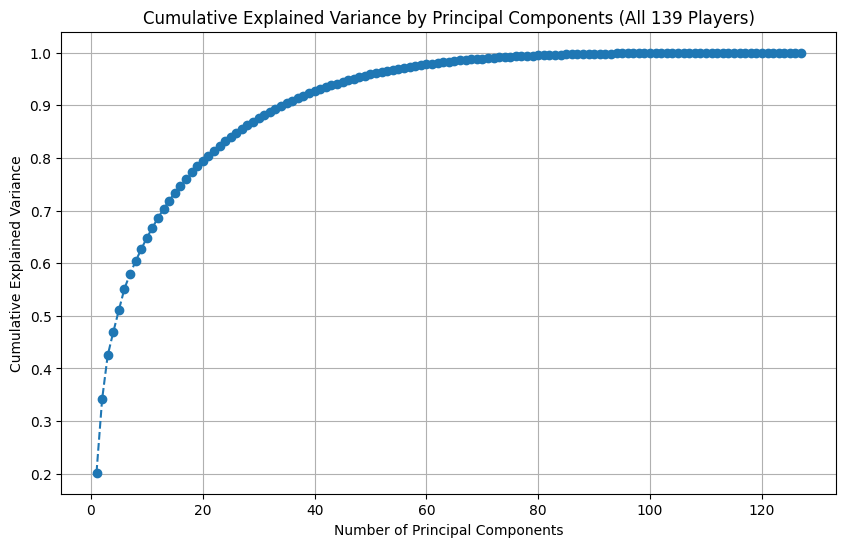

Number of principal components to explain 95% of variance for all 139 players: 47
Cumulative variance explained by 47 components: 0.9504


In [ ]:
# Analyze Explained Variance for all 139 players
import matplotlib.pyplot as plt
import numpy as np

explained_variance_ratio_all_players = pca_all_players.explained_variance_ratio_
cumulative_explained_variance_all_players = np.cumsum(explained_variance_ratio_all_players)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio_all_players) + 1), cumulative_explained_variance_all_players, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components (All 139 Players)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

num_components_95_all_players = np.where(cumulative_explained_variance_all_players >= 0.95)[0][0] + 1

print(f"Number of principal components to explain 95% of variance for all 139 players: {num_components_95_all_players}")
print(f"Cumulative variance explained by {num_components_95_all_players} components: {cumulative_explained_variance_all_players[num_components_95_all_players - 1]:.4f}")

In [ ]:
# Reduce dataset to the identified number of principal components
X_pca_reduced_all_players = X_pca_all_players[:, :num_components_95_all_players]

print(f"Dataset reduced to {X_pca_reduced_all_players.shape[1]} components. New shape: {X_pca_reduced_all_players.shape}")

Dataset reduced to 47 components. New shape: (127, 47)


In [ ]:
# Create df_pca for all 139 players
pc_columns_all_players = [f'PC{i+1}' for i in range(X_pca_reduced_all_players.shape[1])]
df_pca_all_players = pd.DataFrame(data=X_pca_reduced_all_players, columns=pc_columns_all_players, index=df_final.index)

print(f"DataFrame after PCA with {df_pca_all_players.shape[1]} components for all 139 players:")
display(df_pca_all_players.head())

DataFrame after PCA with 47 components for all 139 players:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47
0,7.194168,-2.326391,3.172586,0.368282,-0.054113,-5.743078,1.726708,-1.815727,-1.833447,1.057062,...,-0.963444,-0.626008,-0.304613,1.541153,0.170079,-0.518172,0.210640,-0.130199,0.620339,-0.579412
1,0.790021,0.414940,-2.942152,1.572769,-0.956662,-3.278149,0.378490,1.228665,1.043096,2.263357,...,-0.817366,-0.142751,-0.923518,-0.100115,0.413821,0.309478,-0.217427,-0.427454,-0.050026,-0.071004
2,6.105107,-2.784934,1.673301,1.435361,-0.232345,-3.431060,-0.255447,-2.978759,-0.610468,-0.033774,...,-1.333239,-0.272044,0.231249,0.042956,0.217847,0.160897,0.431839,-0.785390,-0.390079,0.265689
3,3.469140,3.422794,-0.968551,-2.771570,2.604359,-0.426023,-0.386095,-1.444247,0.021063,-0.905965,...,-0.646955,0.028782,-0.952842,-0.737819,1.194045,-0.356728,-0.795897,0.429549,-0.402186,-0.539241
4,5.341270,3.719809,5.590562,-0.136803,-1.884489,1.101167,-4.387159,-0.943312,-1.721962,1.994432,...,-0.136679,-1.077748,-0.574917,0.189938,-1.085661,-0.591390,-0.485751,-0.311392,0.213279,1.064407


### K-Means Clustering con 7 Cluster (All 139 Players)

In [ ]:
from sklearn.cluster import KMeans

# Define the number of clusters as 7, as chosen previously
n_clusters = 7

kmeans_all_players = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)

# Fit KMeans to the PCA-reduced data and get cluster labels
cluster_labels_all_players = kmeans_all_players.fit_predict(X_pca_reduced_all_players)

# Add the cluster labels to the df_pca_all_players DataFrame
df_pca_all_players['cluster'] = cluster_labels_all_players

# Add cluster labels back to the original model DataFrame using the index of df_final
model_with_clusters_all_players = model.copy()

# Create a Series of cluster labels with the same index as df_final
cluster_series_all_players = pd.Series(cluster_labels_all_players, index=df_final.index)

# Map this Series to the model_with_clusters_all_players DataFrame
model_with_clusters_all_players['cluster'] = cluster_series_all_players

print(f"Players clustered into {n_clusters} groups. Cluster labels added to df_pca_all_players and model_with_clusters_all_players.")
display(model_with_clusters_all_players.head())

# Display the count of players per cluster
print("\nPlayer count per cluster (All 139 Players):")
display(model_with_clusters_all_players['cluster'].value_counts().sort_index())

Players clustered into 7 groups. Cluster labels added to df_pca_all_players and model_with_clusters_all_players.


,name,wyId,team_name,birth_date,role,advanced_stats,cluster
11,Matteo Gabbia,405603,Milan,1999-10-21,Defender,"{'playerId': 405603, 'competitionId': 524, 'se...",5.0
15,Samuele Ricci,531696,Milan,2001-08-21,Midfielder,"{'playerId': 531696, 'competitionId': 524, 'se...",3.0
17,Koni De Winter,549480,Milan,2002-06-12,Defender,"{'playerId': 549480, 'competitionId': 524, 'se...",6.0
18,Lorenzo Torriani,632173,Milan,2005-01-31,Goalkeeper,"{'playerId': 632173, 'competitionId': 524, 'se...",1.0
19,Davide Bartesaghi,632175,Milan,2005-12-29,Defender,"{'playerId': 632175, 'competitionId': 524, 'se...",6.0



Player count per cluster (All 139 Players):


,count
cluster,
0.0,1
1.0,4
2.0,3
3.0,7
4.0,5
5.0,2
6.0,10


In [ ]:
display(model_with_clusters_all_players)

,name,wyId,team_name,birth_date,role,advanced_stats,cluster
11,Matteo Gabbia,405603,Milan,1999-10-21,Defender,"{'playerId': 405603, 'competitionId': 524, 'se...",5.0
15,Samuele Ricci,531696,Milan,2001-08-21,Midfielder,"{'playerId': 531696, 'competitionId': 524, 'se...",3.0
17,Koni De Winter,549480,Milan,2002-06-12,Defender,"{'playerId': 549480, 'competitionId': 524, 'se...",6.0
18,Lorenzo Torriani,632173,Milan,2005-01-31,Goalkeeper,"{'playerId': 632173, 'competitionId': 524, 'se...",1.0
19,Davide Bartesaghi,632175,Milan,2005-12-29,Defender,"{'playerId': 632175, 'competitionId': 524, 'se...",6.0
...,...,...,...,...,...,...,...
2874,Marco Nazzaro,630545,Team Altamura,2005-06-11,Midfielder,"{'playerId': 630545, 'competitionId': 520, 'se...",NaN
2875,Lorenzo Peschetola,633809,Team Altamura,2003-02-18,Midfielder,"{'playerId': 633809, 'competitionId': 520, 'se...",NaN
2876,Mattia Florio,637474,Team Altamura,2003-09-05,Forward,"{'playerId': 637474, 'competitionId': 520, 'se...",NaN
2877,Tobia Mogentale,638127,Team Altamura,2005-08-24,Midfielder,"{'playerId': 638127, 'competitionId': 520, 'se...",NaN


### Distribuzione dei Giocatori per Cluster (127 Giocatori Clustered)

/tmp/ipykernel_694/1027809706.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts_all_players.index, y=cluster_counts_all_players.values, palette='viridis')


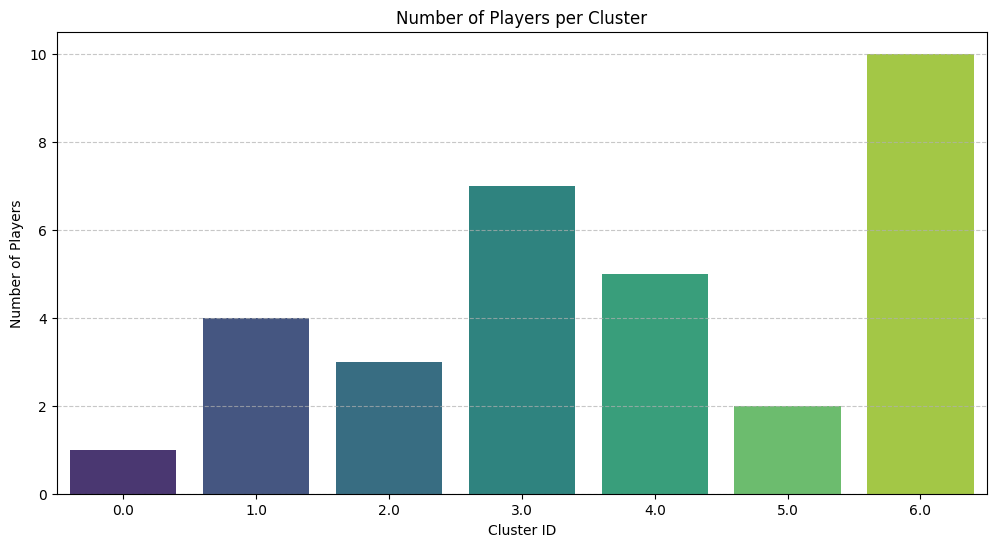

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts of players per cluster from the clustered DataFrame
cluster_counts_all_players = model_with_clusters_all_players['cluster'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=cluster_counts_all_players.index, y=cluster_counts_all_players.values, palette='viridis')
plt.title('Number of Players per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Players')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 17/03


In [ ]:
import pickle
import pandas as pd

with open('/content/drive/MyDrive/Colab Notebooks/df_primavera.pkl', 'rb') as f:
    data = pickle.load(f)

In [ ]:
import pickle

with open("/content/drive/MyDrive/Colab Notebooks/advancedStats.pkl", "rb") as f:
    model = pickle.load(f)

In [ ]:
wyId = 191623 # This is for season 2025-2026

formatted_seasons_matches_url = seasons_matches_url.format(wyId=wyId)

response = requests.get(formatted_seasons_matches_url, auth=HTTPBasicAuth(client_id, client_secret))

if response.ok:
    seasons_matches = response.json()
    print(f"Successfully fetched matches for season {wyId}.")
    # Optionally, you can display a sample of the matches here if needed
    # pprint(seasons_matches.get('matches', [])[:5])
else:
    print(f"Failed to fetch seasons_matches: {response.status_code} - {response.text}")

Successfully fetched matches for season 191623.


In [ ]:
seasons_matches

{'matches': [{'matchId': 5712312,
   'label': 'Cremonese - Fiorentina, 1-4',
   'date': '2026-03-16 20:45:00',
   'dateutc': '2026-03-16 19:45:00',
   'status': 'Played',
   'competitionId': 524,
   'seasonId': 191623,
   'roundId': 4435317,
   'gameweek': 29},
  {'matchId': 5712314,
   'label': 'Lazio - Milan, 1-0',
   'date': '2026-03-15 20:45:00',
   'dateutc': '2026-03-15 19:45:00',
   'status': 'Played',
   'competitionId': 524,
   'seasonId': 191623,
   'roundId': 4435317,
   'gameweek': 29},
  {'matchId': 5712311,
   'label': 'Como - Roma, 2-1',
   'date': '2026-03-15 18:00:00',
   'dateutc': '2026-03-15 17:00:00',
   'status': 'Played',
   'competitionId': 524,
   'seasonId': 191623,
   'roundId': 4435317,
   'gameweek': 29},
  {'matchId': 5712316,
   'label': 'Pisa - Cagliari, 3-1',
   'date': '2026-03-15 15:00:00',
   'dateutc': '2026-03-15 14:00:00',
   'status': 'Played',
   'competitionId': 524,
   'seasonId': 191623,
   'roundId': 4435317,
   'gameweek': 29},
  {'matchId'

In [ ]:
matchWyId = 5712036
playerID = 1016232

formatted_player_match_advanced_stats_url = player_match_advanced_stats_url.format(matchWyId=matchWyId, wyId=playerID)

response = requests.get(formatted_player_match_advanced_stats_url, auth=HTTPBasicAuth(client_id, client_secret))

if response.ok:
    player_match_advanced_stats = response.json()


In [ ]:
player_match_advanced_stats

{'playerId': 1016232,
 'competitionId': 524,
 'seasonId': 191623,
 'positions': [{'position': {'name': 'Left Attacking Midfielder',
    'code': 'lamf'},
   'percent': 100}],
 'total': {'matches': 1,
  'matchesInStart': 1,
  'matchesSubstituted': 1,
  'matchesComingOff': 0,
  'minutesOnField': 92,
  'minutesTagged': 92,
  'goals': 0,
  'assists': 0,
  'shots': 1,
  'headShots': 1,
  'yellowCards': 0,
  'redCards': 0,
  'directRedCards': 0,
  'penalties': 0,
  'linkupPlays': 4,
  'duels': 29,
  'duelsWon': 11,
  'defensiveDuels': 3,
  'defensiveDuelsWon': 0,
  'offensiveDuels': 21,
  'offensiveDuelsWon': 8,
  'aerialDuels': 3,
  'aerialDuelsWon': 2,
  'fouls': 0,
  'passes': 26,
  'successfulPasses': 23,
  'smartPasses': 1,
  'successfulSmartPasses': 0,
  'passesToFinalThird': 2,
  'successfulPassesToFinalThird': 2,
  'crosses': 0,
  'successfulCrosses': 0,
  'forwardPasses': 6,
  'successfulForwardPasses': 4,
  'backPasses': 7,
  'successfulBackPasses': 7,
  'throughPasses': 1,
  'succe

In [ ]:
playerID = 1016232

formatted_players_match = players_match_url.format(wyId=playerID)

response = requests.get(formatted_players_match, auth=HTTPBasicAuth(client_id, client_secret))

if response.ok:
    players_match = response.json()

In [ ]:
players_match

{'matches': [{'matchId': 5712311,
   'label': 'Como - Roma, 2-1',
   'date': '2026-03-15 18:00:00',
   'dateutc': '2026-03-15 17:00:00',
   'status': 'Played',
   'competitionId': 524,
   'seasonId': 191623,
   'roundId': 4435317,
   'gameweek': 29},
  {'matchId': 5712304,
   'label': 'Cagliari - Como, 1-2',
   'date': '2026-03-07 15:00:00',
   'dateutc': '2026-03-07 14:00:00',
   'status': 'Played',
   'competitionId': 524,
   'seasonId': 191623,
   'roundId': 4435317,
   'gameweek': 28},
  {'matchId': 5712292,
   'label': 'Como - Lecce, 3-1',
   'date': '2026-02-28 15:00:00',
   'dateutc': '2026-02-28 14:00:00',
   'status': 'Played',
   'competitionId': 524,
   'seasonId': 191623,
   'roundId': 4435317,
   'gameweek': 27},
  {'matchId': 5712288,
   'label': 'Juventus - Como, 0-2',
   'date': '2026-02-21 15:00:00',
   'dateutc': '2026-02-21 14:00:00',
   'status': 'Played',
   'competitionId': 524,
   'seasonId': 191623,
   'roundId': 4435317,
   'gameweek': 26},
  {'matchId': 571226

In [ ]:
import pandas as pd
from tqdm import tqdm

playerID = 1016232
season_id_2025_2026 = 191623

player_matches_2025_2026 = []
if 'matches' in players_match:
    for match_info in players_match['matches']:
        if match_info.get('seasonId') == season_id_2025_2026:
            player_matches_2025_2026.append(match_info)

print(f"Found {len(player_matches_2025_2026)} matches for player {playerID} in season {season_id_2025_2026}.")

all_player_match_stats_for_season = []

print(f"\nFetching advanced stats for player {playerID} for each match in season {season_id_2025_2026}...")
for match in tqdm(player_matches_2025_2026, desc=f"Fetching stats for player {playerID}"):
    match_wyId = match.get('matchId')
    if not match_wyId:
        continue

    formatted_player_match_advanced_stats_url = player_match_advanced_stats_url.format(
        wyId=playerID,
        matchWyId=match_wyId
    )

    response = requests.get(
        formatted_player_match_advanced_stats_url,
        auth=HTTPBasicAuth(client_id, client_secret)
    )

    if response.ok:
        stats_data = response.json()
        if stats_data: # Ensure stats data is not empty
            stats_data['player_name'] = players_match.get('player', {}).get('name') # Try to get player name from the players_match object
            stats_data['player_wyId'] = playerID
            stats_data['match_wyId'] = match_wyId
            stats_data['match_date'] = match.get('date')
            stats_data['match_label'] = match.get('label')
            all_player_match_stats_for_season.append(stats_data)
    else:
        print(f"Failed to fetch advanced stats for match {match_wyId}: {response.status_code} - {response.text}")

print(f"\nCollected advanced stats for {len(all_player_match_stats_for_season)} player-match combinations for season {season_id_2025_2026}.")

df_player_season_match_stats = pd.DataFrame(all_player_match_stats_for_season)
print("DataFrame of player's season match advanced stats created.")
display(df_player_season_match_stats.head())

Found 26 matches for player 1016232 in season 191623.

Fetching advanced stats for player 1016232 for each match in season 191623...


Fetching stats for player 1016232: 100%|██████████| 26/26 [00:23<00:00,  1.08it/s]


Collected advanced stats for 26 player-match combinations for season 191623.
DataFrame of player's season match advanced stats created.


,playerId,competitionId,seasonId,positions,total,average,percent,roundId,matchId,player_name,player_wyId,match_wyId,match_date,match_label
0,1016232,524,191623,[{'position': {'name': 'Left Attacking Midfiel...,"{'matches': 1, 'matchesInStart': 0, 'matchesSu...","{'passLength': 18.3, 'longPassLength': 0, 'dri...","{'duelsWon': 50, 'defensiveDuelsWon': 0, 'offe...",4435317,5712311,None,1016232,5712311,2026-03-15 18:00:00,"Como - Roma, 2-1"
1,1016232,524,191623,[{'position': {'name': 'Left Attacking Midfiel...,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 13.53, 'longPassLength': 0, 'dr...","{'duelsWon': 18.75, 'defensiveDuelsWon': 12.5,...",4435317,5712304,None,1016232,5712304,2026-03-07 15:00:00,"Cagliari - Como, 1-2"
2,1016232,524,191623,[{'position': {'name': 'Left Attacking Midfiel...,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 18.08, 'longPassLength': 29.76,...","{'duelsWon': 50, 'defensiveDuelsWon': 50, 'off...",4435317,5712292,None,1016232,5712292,2026-02-28 15:00:00,"Como - Lecce, 3-1"
3,1016232,524,191623,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",4435317,5712288,None,1016232,5712288,2026-02-21 15:00:00,"Juventus - Como, 0-2"
4,1016232,524,191623,"[{'position': {'name': 'Attacking Midfielder',...","{'matches': 1, 'matchesInStart': 0, 'matchesSu...","{'passLength': 16.2, 'longPassLength': 0, 'dri...","{'duelsWon': 50, 'defensiveDuelsWon': 0, 'offe...",4435317,5712261,None,1016232,5712261,2026-02-18 20:45:00,"Milan - Como, 1-1"


In [ ]:
df_juventus = model[model['team_name'] == 'Juventus'].copy()
df_juventus = df_juventus.drop(columns=['advanced_stats'], errors='ignore')
display(df_juventus)

,name,wyId,team_name,birth_date,role
56,Manuel Locatelli,286226,Juventus,1998-01-08,Midfielder
58,Andrea Cambiaso,409322,Juventus,2000-02-20,Defender
59,Dušan Vlahović,418950,Juventus,2000-01-28,Forward
61,Michele Di Gregorio,440873,Juventus,1997-07-27,Goalkeeper
71,Fabio Miretti,609117,Juventus,2003-08-03,Midfielder
74,Kenan Yıldız,759543,Juventus,2005-05-04,Forward


In [ ]:
import pandas as pd
from tqdm import tqdm

# Define the target season ID
season_id_2025_2026 = 191623

# List to store all collected advanced stats for all Juventus players across all matches
all_juventus_players_match_stats = []

print(f"Starting to fetch match advanced stats for all {len(df_juventus)} Juventus players for season {season_id_2025_2026}...")

# Iterate through each player in df_juventus
for index, player_row in tqdm(df_juventus.iterrows(), total=len(df_juventus), desc="Processing Juventus Players"):
    player_wyId = player_row['wyId']
    player_name = player_row['name']

    # 1. Fetch all matches for the current player
    formatted_players_match_url = players_match_url.format(wyId=player_wyId)
    response_player_matches = requests.get(
        formatted_players_match_url,
        auth=HTTPBasicAuth(client_id, client_secret)
    )

    if not response_player_matches.ok:
        print(f"Warning: Failed to fetch matches for player {player_name} (WyId: {player_wyId}): {response_player_matches.status_code} - {response_player_matches.text}")
        continue

    player_matches_data = response_player_matches.json()
    player_all_matches = player_matches_data.get('matches', [])

    # 2. Filter matches for the 2025-2026 season
    player_matches_season_filtered = [
        match_info for match_info in player_all_matches
        if match_info.get('seasonId') == season_id_2025_2026
    ]

    if not player_matches_season_filtered:
        # print(f"No matches found for player {player_name} (WyId: {player_wyId}) in season {season_id_2025_2026}.")
        continue

    # 3. Fetch advanced stats for each filtered match
    for match in player_matches_season_filtered:
        match_wyId = match.get('matchId')
        match_date = match.get('date')
        match_label = match.get('label')

        if not match_wyId:
            continue

        formatted_player_match_advanced_stats_url = player_match_advanced_stats_url.format(
            wyId=player_wyId,
            matchWyId=match_wyId
        )

        response_match_stats = requests.get(
            formatted_player_match_advanced_stats_url,
            auth=HTTPBasicAuth(client_id, client_secret)
        )

        if response_match_stats.ok:
            stats_data = response_match_stats.json()
            if stats_data: # Ensure stats data is not empty
                stats_data['player_name'] = player_name
                stats_data['player_wyId'] = player_wyId
                stats_data['match_wyId'] = match_wyId
                stats_data['match_date'] = match_date
                stats_data['match_label'] = match_label
                all_juventus_players_match_stats.append(stats_data)
        # else:
            # print(f"Failed to fetch advanced stats for player {player_name} (WyId: {player_wyId}) in match {match_wyId}: {response_match_stats.status_code} - {response_match_stats.text}")

print(f"\nCollected advanced stats for {len(all_juventus_players_match_stats)} player-match combinations for Juventus players.")

# Convert the collected data into a DataFrame
df_all_juventus_players_match_stats = pd.DataFrame(all_juventus_players_match_stats)

print("DataFrame of all Juventus players' season match advanced stats created.")
display(df_all_juventus_players_match_stats)

Starting to fetch match advanced stats for all 6 Juventus players for season 191623...


Processing Juventus Players:   0%|          | 0/6 [00:06<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
df_all_juventus_players_match_stats

,playerId,competitionId,seasonId,positions,total,average,percent,roundId,matchId,player_name,player_wyId,match_wyId,match_date,match_label
0,286226,524,191623,[{'position': {'name': 'Right Defensive Midfie...,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 19.06, 'longPassLength': 34.75,...","{'duelsWon': 23.08, 'defensiveDuelsWon': 20, '...",4435317,5712319,Manuel Locatelli,286226,5712319,2026-03-14 20:45:00,"Udinese - Juventus, 0-1"
1,286226,524,191623,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 19.96, 'longPassLength': 54.45,...","{'duelsWon': 7.14, 'defensiveDuelsWon': 12.5, ...",4435317,5712307,Manuel Locatelli,286226,5712307,2026-03-07 20:45:00,"Juventus - Pisa, 4-0"
2,286226,524,191623,[{'position': {'name': 'Right Centre Midfielde...,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 22.67, 'longPassLength': 45.64,...","{'duelsWon': 41.18, 'defensiveDuelsWon': 25, '...",4435317,5712288,Manuel Locatelli,286226,5712288,2026-02-21 15:00:00,"Juventus - Como, 0-2"
3,286226,524,191623,[{'position': {'name': 'Right Centre Midfielde...,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 21.84, 'longPassLength': 40.75,...","{'duelsWon': 64.71, 'defensiveDuelsWon': 50, '...",4435317,5712274,Manuel Locatelli,286226,5712274,2026-02-14 20:45:00,"Internazionale - Juventus, 3-2"
4,286226,524,191623,[{'position': {'name': 'Right Centre Midfielde...,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 22.24, 'longPassLength': 43.4, ...","{'duelsWon': 54.55, 'defensiveDuelsWon': 40, '...",4435317,5712267,Manuel Locatelli,286226,5712267,2026-02-08 20:45:00,"Juventus - Lazio, 2-2"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,759543,524,191623,"[{'position': {'name': 'Attacking Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 17.68, 'longPassLength': 20.23,...","{'duelsWon': 50, 'defensiveDuelsWon': 0, 'offe...",4435317,5712076,Kenan Yıldız,759543,5712076,2025-09-27 18:00:00,"Juventus - Atalanta, 1-1"
143,759543,524,191623,"[{'position': {'name': 'Attacking Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 15.41, 'longPassLength': 27.16,...","{'duelsWon': 27.27, 'defensiveDuelsWon': 0, 'o...",4435317,5712070,Kenan Yıldız,759543,5712070,2025-09-20 18:00:00,"Hellas Verona - Juventus, 1-1"
144,759543,524,191623,"[{'position': {'name': 'Attacking Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 14.99, 'longPassLength': 42.4, ...","{'duelsWon': 50, 'defensiveDuelsWon': 33.33, '...",4435317,5712052,Kenan Yıldız,759543,5712052,2025-09-13 18:00:00,"Juventus - Internazionale, 4-3"
145,759543,524,191623,"[{'position': {'name': 'Attacking Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 14.76, 'longPassLength': 0, 'dr...","{'duelsWon': 42.31, 'defensiveDuelsWon': 50, '...",4435317,5712047,Kenan Yıldız,759543,5712047,2025-08-31 18:30:00,"Genoa - Juventus, 0-1"


In [ ]:
# Get the list of team names for Serie A
serie_a_teams = [team['name'] for team in teams_by_competition_direct['Serie A']]

# Filter the 'model' DataFrame to include only players from Serie A teams
df_serie_a_players = model[model['team_name'].isin(serie_a_teams)].copy()

print(f"Total players in Serie A: {len(df_serie_a_players)}")


Total players in Serie A: 180


In [ ]:
WyId_serieA_players = df_serie_a_players['wyId'].tolist()


CREAZIONE DB CON STATS GIOCATORI SERIE A OGNI PARTITA PER STAGIONE

In [ ]:
import pandas as pd
from tqdm import tqdm

# Define the target season ID for 2025-2026 Serie A
season_id_2025_2026 = 191623

# List to store all collected advanced stats for all Serie A players across all matches
all_serie_a_players_match_stats = []

print(f"Starting to fetch match advanced stats for all {len(df_serie_a_players)} Serie A players for season {season_id_2025_2026}...")

# Iterate through each player in df_serie_a_players
for index, player_row in tqdm(df_serie_a_players.iterrows(), total=len(df_serie_a_players), desc="Processing Serie A Players"):
    player_wyId = player_row['wyId']
    player_name = player_row['name']

    # 1. Fetch all matches for the current player
    formatted_players_match_url = players_match_url.format(wyId=player_wyId)
    response_player_matches = requests.get(
        formatted_players_match_url,
        auth=HTTPBasicAuth(client_id, client_secret)
    )

    if not response_player_matches.ok:
        print(f"Warning: Failed to fetch matches for player {player_name} (WyId: {player_wyId}): {response_player_matches.status_code} - {response_player_matches.text}")
        continue

    player_matches_data = response_player_matches.json()
    player_all_matches = player_matches_data.get('matches', [])

    # 2. Filter matches for the 2025-2026 season
    player_matches_season_filtered = [
        match_info for match_info in player_all_matches
        if match_info.get('seasonId') == season_id_2025_2026
    ]

    if not player_matches_season_filtered:
        # print(f"No matches found for player {player_name} (WyId: {player_wyId}) in season {season_id_2025_2026}.")
        continue

    # 3. Fetch advanced stats for each filtered match
    for match in player_matches_season_filtered:
        match_wyId = match.get('matchId')
        match_date = match.get('date')
        match_label = match.get('label')

        if not match_wyId:
            continue

        formatted_player_match_advanced_stats_url = player_match_advanced_stats_url.format(
            wyId=player_wyId,
            matchWyId=match_wyId
        )

        response_match_stats = requests.get(
            formatted_player_match_advanced_stats_url,
            auth=HTTPBasicAuth(client_id, client_secret)
        )

        if response_match_stats.ok:
            stats_data = response_match_stats.json()
            if stats_data: # Ensure stats data is not empty
                stats_data['player_name'] = player_name
                stats_data['player_wyId'] = player_wyId
                stats_data['match_wyId'] = match_wyId
                stats_data['match_date'] = match_date
                stats_data['match_label'] = match_label
                all_serie_a_players_match_stats.append(stats_data)
        # else:
            # print(f"Failed to fetch advanced stats for player {player_name} (WyId: {player_wyId}) in match {match_wyId}: {response_match_stats.status_code} - {response_match_stats.text}")

print(f"\nCollected advanced stats for {len(all_serie_a_players_match_stats)} player-match combinations for Serie A players.")

# Convert the collected data into a DataFrame
df_all_serie_a_players_match_stats = pd.DataFrame(all_serie_a_players_match_stats)

print("DataFrame of all Serie A players' season match advanced stats created.")
display(df_all_serie_a_players_match_stats.head())

Starting to fetch match advanced stats for all 180 Serie A players for season 191623...


Processing Serie A Players: 100%|██████████| 180/180 [1:28:03<00:00, 29.35s/it]



Collected advanced stats for 4003 player-match combinations for Serie A players.
DataFrame of all Serie A players' season match advanced stats created.


,playerId,competitionId,seasonId,positions,total,average,percent,roundId,matchId,player_name,player_wyId,match_wyId,match_date,match_label
0,405603,524,191623,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",4435317,5712281,Matteo Gabbia,405603,5712281,2026-02-22 18:00:00,"Milan - Parma, 0-1"
1,405603,524,191623,"[{'position': {'name': 'Centre Back', 'code': ...","{'matches': 1, 'matchesInStart': 0, 'matchesSu...","{'passLength': 20.69, 'longPassLength': 41.35,...","{'duelsWon': 40, 'defensiveDuelsWon': 0, 'offe...",4435317,5712261,Matteo Gabbia,405603,5712261,2026-02-18 20:45:00,"Milan - Como, 1-1"
2,405603,524,191623,"[{'position': {'name': 'Centre Back', 'code': ...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 21.55, 'longPassLength': 44.06,...","{'duelsWon': 50, 'defensiveDuelsWon': 0, 'offe...",4435317,5712278,Matteo Gabbia,405603,5712278,2026-02-13 20:45:00,"Pisa - Milan, 1-2"
3,405603,524,191623,"[{'position': {'name': 'Centre Back', 'code': ...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 19.56, 'longPassLength': 46.09,...","{'duelsWon': 12.5, 'defensiveDuelsWon': 25, 'o...",4435317,5712251,Matteo Gabbia,405603,5712251,2026-02-03 20:45:00,"Bologna - Milan, 0-3"
4,405603,524,191623,"[{'position': {'name': 'Centre Back', 'code': ...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 21.73, 'longPassLength': 44.43,...","{'duelsWon': 61.54, 'defensiveDuelsWon': 42.86...",4435317,5712241,Matteo Gabbia,405603,5712241,2026-01-25 20:45:00,"Roma - Milan, 1-1"


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/statsBYmatchSerieA.pkl"
df_all_serie_a_players_match_stats.to_pickle(file_path)

# 19/03

In [ ]:
import pickle
import pandas as pd

with open('/content/drive/MyDrive/Colab Notebooks/statsBYmatchSerieA_25_26.pkl', 'rb') as f:
    db_2025_26 = pickle.load(f)

In [ ]:
import pickle

with open("/content/drive/MyDrive/Colab Notebooks/advancedStats.pkl", "rb") as f:
    model = pickle.load(f)

In [ ]:
# Get the list of team names for Serie A
serie_a_teams = [team['name'] for team in teams_by_competition_direct['Serie A']]

# Filter the 'model' DataFrame to include only players from Serie A teams
df_serie_a_players = model[model['team_name'].isin(serie_a_teams)].copy()

WyId_serieA_players = df_serie_a_players['wyId'].tolist()


# Funzione per avere le stats delle partite di una stagione selezionata, per una lista di player WyId selezionati, prendendo le caratteristiche da un db preesistente (solitamente model)

In [ ]:
import pandas as pd
from tqdm import tqdm
import requests
from requests.auth import HTTPBasicAuth
import time # Import time for sleep

def get_player_seasonal_match_stats(player_ids, season_id, player_data_df, throttle_delay=0.1):
    """
    Fetches advanced match statistics for a list of players for a specific season.

    Args:
        player_ids (list): A list of player Wyscout IDs.
        season_id (int): The Wyscout ID for the target season.
        player_data_df (pd.DataFrame): DataFrame containing player details (e.g., 'name', 'wyId').
                                        This is typically the 'model' DataFrame.
        throttle_delay (float): Delay in seconds between API requests to prevent overwhelming the server.

    Returns:
        pd.DataFrame: A DataFrame containing advanced match stats for the specified players and season.
    """
    all_players_match_stats = []

    print(f"Starting to fetch match advanced stats for {len(player_ids)} players for season {season_id}...")

    filtered_players_df = player_data_df[player_data_df['wyId'].isin(player_ids)]

    for index, player_row in tqdm(filtered_players_df.iterrows(), total=len(filtered_players_df), desc="Processing Players"):
        player_wyId = player_row['wyId']
        player_name = player_row['name']

        # 1. Fetch all matches for the current player
        try:
            formatted_players_match_url = players_match_url.format(wyId=player_wyId)
            response_player_matches = requests.get(
                formatted_players_match_url,
                auth=HTTPBasicAuth(client_id, client_secret),
                timeout=30 # Increased timeout
            )
            response_player_matches.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)
        except requests.exceptions.RequestException as e:
            print(f"Warning: Failed to fetch matches for player {player_name} (WyId: {player_wyId}) due to network/API error: {e}. Skipping this player.")
            time.sleep(throttle_delay * 5) # Longer pause on error
            continue # Skip to the next player

        player_matches_data = response_player_matches.json()
        player_all_matches = player_matches_data.get('matches', [])

        # 2. Filter matches for the specified season
        player_matches_season_filtered = [
            match_info for match_info in player_all_matches
            if match_info.get('seasonId') == season_id
        ]

        if not player_matches_season_filtered:
            continue

        # 3. Fetch advanced stats for each filtered match
        for match in player_matches_season_filtered:
            match_wyId = match.get('matchId')
            if not match_wyId:
                continue

            match_date = match.get('date')
            match_label = match.get('label')

            try:
                formatted_player_match_advanced_stats_url = player_match_advanced_stats_url.format(
                    wyId=player_wyId,
                    matchWyId=match_wyId
                )

                response_match_stats = requests.get(
                    formatted_player_match_advanced_stats_url,
                    auth=HTTPBasicAuth(client_id, client_secret),
                    timeout=60 # Increased timeout
                )
                response_match_stats.raise_for_status()
            except requests.exceptions.RequestException as e:
                print(f"Warning: Failed to fetch advanced stats for player {player_name} (WyId: {player_wyId}) in match {match_wyId} due to network/API error: {e}. Skipping this match.")
                time.sleep(throttle_delay * 5) # Longer pause on error
                continue # Skip this specific match's stats if it fails.

            stats_data = response_match_stats.json()
            if stats_data: # Ensure stats data is not empty
                stats_data['player_name'] = player_name
                stats_data['player_wyId'] = player_wyId
                stats_data['match_wyId'] = match_wyId
                stats_data['match_date'] = match_date
                stats_data['match_label'] = match_label
                all_players_match_stats.append(stats_data)
            time.sleep(throttle_delay) # Pause after each match request

    print(f"\nCollected advanced stats for {len(all_players_match_stats)} player-match combinations.")

    df_players_match_stats = pd.DataFrame(all_players_match_stats)

    print("DataFrame of players' season match advanced stats created.")
    return df_players_match_stats

print("Function 'get_player_seasonal_match_stats' defined (with improved robustness).")

Function 'get_player_seasonal_match_stats' defined (with improved robustness).


In [ ]:
# creo il db con tutte le stats delle partite della stagione 2024-25 dei giocatori di serie A

target_season_id = 185942 # SerieB_19_20

df_statsBYmatchPrimavera_18_19 = get_player_seasonal_match_stats(WyId_serieA_players, target_season_id, model)

Starting to fetch match advanced stats for 180 players for season 185942...


Processing Players:   1%|          | 1/180 [00:00<00:44,  3.99it/s]

Processing Players:  11%|█         | 20/180 [01:05<05:26,  2.04s/it]

Processing Players:  12%|█▏        | 22/180 [01:38<21:16,  8.08s/it]

Processing Players:  22%|██▏       | 39/180 [02:40<31:39, 13.47s/it]

...

Processing Players:  72%|███████▏  | 130/180 [08:42<00:17,  2.81it/s]

Processing Players:  82%|████████▏ | 148/180 [09:11<00:09,  3.44it/s]

Processing Players:  96%|█████████▌| 173/180 [09:39<00:02,  2.73it/s]

Processing Players: 100%|██████████| 180/180 [09:52<00:00,  3.29s/it]


Collected advanced stats for 590 player-match combinations.
DataFrame of players' season match advanced stats created.


In [ ]:
df_statsBYmatchSerieB_22_23.head(10)


,playerId,competitionId,seasonId,positions,total,average,percent,roundId,matchId,player_name,player_wyId,match_wyId,match_date,match_label
0,405603,524,187528,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",4424524,5251284,Matteo Gabbia,405603,5251284,2022-05-22 18:00:00,"Sassuolo - Milan, 0-3"
1,405603,524,187528,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",4424524,5251273,Matteo Gabbia,405603,5251273,2022-05-15 18:00:00,"Milan - Atalanta, 2-0"
2,405603,524,187528,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",4424524,5251260,Matteo Gabbia,405603,5251260,2022-05-08 20:45:00,"Hellas Verona - Milan, 1-3"
3,405603,524,187528,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",4424524,5251252,Matteo Gabbia,405603,5251252,2022-05-01 15:00:00,"Milan - Fiorentina, 1-0"
4,405603,524,187528,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",4424524,5251243,Matteo Gabbia,405603,5251243,2022-04-24 20:45:00,"Lazio - Milan, 1-2"
5,405603,524,187528,"[{'position': {'name': 'Right Centre Back', 'c...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 29.24, 'longPassLength': 47.99,...","{'duelsWon': 50, 'defensiveDuelsWon': 14.29, '...",4424524,5251233,Matteo Gabbia,405603,5251233,2022-04-15 21:00:00,"Milan - Genoa, 2-0"
6,405603,524,187528,"[{'position': {'name': 'Left Centre Back', 'co...","{'matches': 1, 'matchesInStart': 0, 'matchesSu...","{'passLength': 14.33, 'longPassLength': 0, 'dr...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",4424524,5251226,Matteo Gabbia,405603,5251226,2022-04-10 20:45:00,"Torino - Milan, 0-0"
7,405603,524,187528,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",4424524,5251213,Matteo Gabbia,405603,5251213,2022-04-04 20:45:00,"Milan - Bologna, 0-0"
8,405603,524,187528,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",4424524,5251199,Matteo Gabbia,405603,5251199,2022-03-19 20:45:00,"Cagliari - Milan, 0-1"
9,405603,524,187528,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",4424524,5251192,Matteo Gabbia,405603,5251192,2022-03-12 20:45:00,"Milan - Empoli, 1-0"


unione df stagioni


In [ ]:
import pickle
import pandas as pd


with open('/content/drive/MyDrive/Colab Notebooks/db_storico_match.pkl', 'rb') as f:
    db_storico_match = pickle.load(f)

In [ ]:
db_storico_match = pd.concat([df_statsBYmatchPrimavera_18_19, db_storico_match], ignore_index=True)
print(f"db_storico_match aggiornato, match totali presenti: {len(db_storico_match)}")

db_storico_match aggiornato, match totali presenti: 38347


In [ ]:
player_counts_updated = db_storico_match['player_name'].value_counts()
print("Conteggio aggiornato delle righe per ciascun giocatore nel db_storico_match:")
display(player_counts_updated)

Conteggio aggiornato delle righe per ciascun giocatore nel db_storico_match:


,count
player_name,
Emil Audero Mulyadi,396
Simone Perilli,392
Piotr Zieliński,386
Lorenzo Montipò,385
Ivan Provedel,382
...,...
Mathias Ferante,17
Adrian Lickunas,12
Eman Košpo,11


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/db_storico_match.pkl"
db_storico_match.to_pickle(file_path)

# 23/03

In [ ]:
import pickle
import pandas as pd


with open('/content/drive/MyDrive/Colab Notebooks/db_storico_match.pkl', 'rb') as f:
    db_storico_match = pickle.load(f)

In [ ]:
import pandas as pd

print("DataFrame Info:")
db_storico_match.info()

print("\nFirst 5 rows of db_storico_match:")
display(db_storico_match.head())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 27478 entries, 0 to 38346
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   playerId       27478 non-null  int64 
 1   competitionId  27478 non-null  int64 
 2   seasonId       27478 non-null  int64 
 3   positions      27478 non-null  object
 4   total          27478 non-null  object
 5   average        27478 non-null  object
 6   percent        27478 non-null  object
 7   roundId        27478 non-null  int64 
 8   matchId        27478 non-null  int64 
 9   player_name    27478 non-null  object
 10  player_wyId    27478 non-null  int64 
 11  match_wyId     27478 non-null  int64 
 12  match_date     27478 non-null  object
 13  match_label    27478 non-null  object
dtypes: int64(7), object(7)
memory usage: 3.1+ MB

First 5 rows of db_storico_match:


,playerId,competitionId,seasonId,positions,total,average,percent,roundId,matchId,player_name,player_wyId,match_wyId,match_date,match_label
0,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 20.36, 'longPassLength': 37.16,...","{'duelsWon': 55.17, 'defensiveDuelsWon': 45.45...",4417644,2828349,Samuele Ricci,531696,2828349,2019-06-05 15:00:00,"Empoli U19 - Genoa U19, 3-1"
1,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 16.48, 'longPassLength': 41.54,...","{'duelsWon': 58.62, 'defensiveDuelsWon': 25, '...",4417644,2828348,Samuele Ricci,531696,2828348,2019-06-01 15:00:00,"Genoa U19 - Empoli U19, 1-1"
2,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 24.5, 'longPassLength': 48.64, ...","{'duelsWon': 35.29, 'defensiveDuelsWon': 23.08...",4417642,2782689,Samuele Ricci,531696,2782689,2019-05-25 15:00:00,"Empoli U19 - Atalanta U19, 2-4"
3,531696,516,185942,"[{'position': {'name': 'Left Back', 'code': 'l...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 21.39, 'longPassLength': 44.28,...","{'duelsWon': 68.18, 'defensiveDuelsWon': 37.5,...",4417642,2782685,Samuele Ricci,531696,2782685,2019-05-18 15:00:00,"Palermo U19 - Empoli U19, 0-0"
4,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 18.5, 'longPassLength': 40, 'dr...","{'duelsWon': 57.14, 'defensiveDuelsWon': 25, '...",4417642,2782673,Samuele Ricci,531696,2782673,2019-05-11 15:00:00,"Empoli U19 - Chievo Verona U19, 1-2"


In [ ]:
print("Missing values per column:")
display(db_storico_match.isnull().sum()[db_storico_match.isnull().sum() > 0])

Missing values per column:


,0


In [ ]:
duplicate_rows = db_storico_match[db_storico_match.duplicated(subset=['player_wyId', 'match_wyId', 'seasonId'], keep=False)]

if not duplicate_rows.empty:
    print(f"\nFound {len(duplicate_rows)} duplicate player-match-season entries (showing first 10):")
    display(duplicate_rows.sort_values(by=['player_wyId', 'match_wyId', 'seasonId']).head(10))
else:
    print("\nNo duplicate player-match-season entries found.")


No duplicate player-match-season entries found.


In [ ]:
# Extract 'minutesOnField' from the 'total' column and convert to numeric, handling potential errors
def get_minutes_on_field(total_stats):
    if isinstance(total_stats, dict):
        return total_stats.get('minutesOnField', 0)
    return 0

db_storico_match['minutesOnField'] = db_storico_match['total'].apply(get_minutes_on_field)

# Filter out rows where 'minutesOnField' is less than 10
initial_rows = len(db_storico_match)
db_storico_match = db_storico_match[db_storico_match['minutesOnField'] >= 10].copy()

# Drop the temporary 'minutesOnField' column if it's no longer needed
db_storico_match = db_storico_match.drop(columns=['minutesOnField'])

final_rows = len(db_storico_match)
print(f"Original rows: {initial_rows}")
print(f"Rows after filtering minutesOnField >= 10: {final_rows}")
print(f"Removed {initial_rows - final_rows} rows where minutesOnField was less than 10.")

display(db_storico_match.head())

Original rows: 38347
Rows after filtering minutesOnField >= 10: 27478
Removed 10869 rows where minutesOnField was less than 10.


,playerId,competitionId,seasonId,positions,total,average,percent,roundId,matchId,player_name,player_wyId,match_wyId,match_date,match_label
0,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 20.36, 'longPassLength': 37.16,...","{'duelsWon': 55.17, 'defensiveDuelsWon': 45.45...",4417644,2828349,Samuele Ricci,531696,2828349,2019-06-05 15:00:00,"Empoli U19 - Genoa U19, 3-1"
1,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 16.48, 'longPassLength': 41.54,...","{'duelsWon': 58.62, 'defensiveDuelsWon': 25, '...",4417644,2828348,Samuele Ricci,531696,2828348,2019-06-01 15:00:00,"Genoa U19 - Empoli U19, 1-1"
2,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 24.5, 'longPassLength': 48.64, ...","{'duelsWon': 35.29, 'defensiveDuelsWon': 23.08...",4417642,2782689,Samuele Ricci,531696,2782689,2019-05-25 15:00:00,"Empoli U19 - Atalanta U19, 2-4"
3,531696,516,185942,"[{'position': {'name': 'Left Back', 'code': 'l...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 21.39, 'longPassLength': 44.28,...","{'duelsWon': 68.18, 'defensiveDuelsWon': 37.5,...",4417642,2782685,Samuele Ricci,531696,2782685,2019-05-18 15:00:00,"Palermo U19 - Empoli U19, 0-0"
4,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 18.5, 'longPassLength': 40, 'dr...","{'duelsWon': 57.14, 'defensiveDuelsWon': 25, '...",4417642,2782673,Samuele Ricci,531696,2782673,2019-05-11 15:00:00,"Empoli U19 - Chievo Verona U19, 1-2"


In [ ]:
display(db_storico_match.head())

,playerId,competitionId,seasonId,positions,total,average,percent,roundId,matchId,player_name,player_wyId,match_wyId,match_date,match_label
0,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 20.36, 'longPassLength': 37.16,...","{'duelsWon': 55.17, 'defensiveDuelsWon': 45.45...",4417644,2828349,Samuele Ricci,531696,2828349,2019-06-05 15:00:00,"Empoli U19 - Genoa U19, 3-1"
1,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 16.48, 'longPassLength': 41.54,...","{'duelsWon': 58.62, 'defensiveDuelsWon': 25, '...",4417644,2828348,Samuele Ricci,531696,2828348,2019-06-01 15:00:00,"Genoa U19 - Empoli U19, 1-1"
2,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 24.5, 'longPassLength': 48.64, ...","{'duelsWon': 35.29, 'defensiveDuelsWon': 23.08...",4417642,2782689,Samuele Ricci,531696,2782689,2019-05-25 15:00:00,"Empoli U19 - Atalanta U19, 2-4"
3,531696,516,185942,"[{'position': {'name': 'Left Back', 'code': 'l...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 21.39, 'longPassLength': 44.28,...","{'duelsWon': 68.18, 'defensiveDuelsWon': 37.5,...",4417642,2782685,Samuele Ricci,531696,2782685,2019-05-18 15:00:00,"Palermo U19 - Empoli U19, 0-0"
4,531696,516,185942,"[{'position': {'name': 'Defensive Midfielder',...","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 18.5, 'longPassLength': 40, 'dr...","{'duelsWon': 57.14, 'defensiveDuelsWon': 25, '...",4417642,2782673,Samuele Ricci,531696,2782673,2019-05-11 15:00:00,"Empoli U19 - Chievo Verona U19, 1-2"


In [ ]:
# Remove 'player_wyId' and 'match_wyId' columns
db_storico_match = db_storico_match.drop(columns=['player_wyId', 'match_wyId', 'roundId','match_label'])


In [ ]:
import plotly.express as px

# Count the occurrences of each seasonId (re-using the previously computed series)
season_id_counts = db_storico_match['seasonId'].value_counts().sort_index()

# Convert the series to a DataFrame for Plotly
df_season_counts = season_id_counts.reset_index()
df_season_counts.columns = ['Season ID', 'Number of Entries']

# Create the interactive bar plot
fig = px.bar(df_season_counts,
             x='Season ID',
             y='Number of Entries',
             title='Number of Entries per Season ID in db_storico_match',
             labels={'Season ID': 'Season ID', 'Number of Entries': 'Number of Entries'},
             template='plotly_white') # Use a clean template

fig.update_xaxes(type='category') # Treat Season ID as a category
fig.show()

In [ ]:
import plotly.express as px

# Group by competitionId and seasonId and count occurrences
competition_season_counts = db_storico_match.groupby(['competitionId', 'seasonId']).size().reset_index(name='Number of Entries')

# Create a grouped bar chart
fig = px.bar(competition_season_counts,
             x='competitionId',
             y='Number of Entries',
             color='seasonId', # This will create stacked bars for each season within a competition
             title='Distribution of Matches by Competition ID and Season ID',
             labels={'competitionId': 'Competition ID', 'seasonId': 'Season ID', 'Number of Entries': 'Number of Entries'},
             template='plotly_white')

fig.update_xaxes(type='category') # Treat competitionId as a category
fig.show()

In [ ]:
# Function to extract all position names
def get_all_position_names(positions_list):
    if positions_list and isinstance(positions_list, list):
        position_names = []
        for position_data in positions_list:
            if isinstance(position_data, dict) and 'position' in position_data:
                position_name = position_data['position'].get('name')
                if position_name:
                    position_names.append(position_name)
        return ', '.join(position_names) if position_names else None
    return None # Return None if no valid positions are found

# Apply the function to the 'positions' column
db_storico_match['positions'] = db_storico_match['positions'].apply(get_all_position_names)


In [ ]:
display(db_storico_match.head())

,playerId,competitionId,seasonId,positions,total,average,percent,matchId,player_name,match_date
0,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 20.36, 'longPassLength': 37.16,...","{'duelsWon': 55.17, 'defensiveDuelsWon': 45.45...",2828349,Samuele Ricci,2019-06-05 15:00:00
1,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 16.48, 'longPassLength': 41.54,...","{'duelsWon': 58.62, 'defensiveDuelsWon': 25, '...",2828348,Samuele Ricci,2019-06-01 15:00:00
2,531696,516,185942,"Defensive Midfielder, Left Centre Midfielder","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 24.5, 'longPassLength': 48.64, ...","{'duelsWon': 35.29, 'defensiveDuelsWon': 23.08...",2782689,Samuele Ricci,2019-05-25 15:00:00
3,531696,516,185942,Left Back,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 21.39, 'longPassLength': 44.28,...","{'duelsWon': 68.18, 'defensiveDuelsWon': 37.5,...",2782685,Samuele Ricci,2019-05-18 15:00:00
4,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 18.5, 'longPassLength': 40, 'dr...","{'duelsWon': 57.14, 'defensiveDuelsWon': 25, '...",2782673,Samuele Ricci,2019-05-11 15:00:00


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/db_storico_match_CLEAN.pkl"
db_storico_match.to_pickle(file_path)

In [ ]:
unique_positions = set()
for positions_str in db_storico_match['positions'].dropna():
    # Split the comma-separated string and add each position to the set
    for position in positions_str.split(', '):
        unique_positions.add(position.strip())

# Convert the set to a sorted list for a clean display
list_unique_positions = sorted(list(unique_positions))

print("Unique Player Positions:")
for position in list_unique_positions:
    print(f"- {position}")

Unique Player Positions:
- Attacking Midfielder
- Centre Back
- Defensive Midfielder
- Goalkeeper
- Left Attacking Midfielder
- Left Back
- Left Back (5 at the back)
- Left Centre Back
- Left Centre Back (3 at the back)
- Left Centre Midfielder
- Left Defensive Midfielder
- Left Wing Forward
- Left Wingback
- Left Winger
- Right Attacking Midfielder
- Right Back
- Right Back (5 at the back)
- Right Centre Back
- Right Centre Back (3 at the back)
- Right Centre Midfielder
- Right Defensive Midfielder
- Right Wing Forward
- Right Wingback
- Right Winger
- Striker


In [ ]:
db_storico_match

,playerId,competitionId,seasonId,positions,total,average,percent,matchId,player_name,match_date
0,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 20.36, 'longPassLength': 37.16,...","{'duelsWon': 55.17, 'defensiveDuelsWon': 45.45...",2828349,Samuele Ricci,2019-06-05 15:00:00
1,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 16.48, 'longPassLength': 41.54,...","{'duelsWon': 58.62, 'defensiveDuelsWon': 25, '...",2828348,Samuele Ricci,2019-06-01 15:00:00
2,531696,516,185942,"Defensive Midfielder, Left Centre Midfielder","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 24.5, 'longPassLength': 48.64, ...","{'duelsWon': 35.29, 'defensiveDuelsWon': 23.08...",2782689,Samuele Ricci,2019-05-25 15:00:00
3,531696,516,185942,Left Back,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 21.39, 'longPassLength': 44.28,...","{'duelsWon': 68.18, 'defensiveDuelsWon': 37.5,...",2782685,Samuele Ricci,2019-05-18 15:00:00
4,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 18.5, 'longPassLength': 40, 'dr...","{'duelsWon': 57.14, 'defensiveDuelsWon': 25, '...",2782673,Samuele Ricci,2019-05-11 15:00:00
...,...,...,...,...,...,...,...,...,...,...
38342,743480,524,191623,Left Centre Back,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 18.43, 'longPassLength': 51.71,...","{'duelsWon': 33.33, 'defensiveDuelsWon': 0, 'o...",5712080,Tarik Muharemović,2025-09-28 12:30:00
38343,743480,524,191623,Left Centre Back,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 25.25, 'longPassLength': 38.22,...","{'duelsWon': 47.37, 'defensiveDuelsWon': 16.67...",5712064,Tarik Muharemović,2025-09-21 20:45:00
38344,743480,524,191623,Left Centre Back,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 23.13, 'longPassLength': 50.92,...","{'duelsWon': 42.86, 'defensiveDuelsWon': 33.33...",5712057,Tarik Muharemović,2025-09-14 18:00:00
38345,743480,524,191623,Left Centre Back,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 24.07, 'longPassLength': 47.53,...","{'duelsWon': 72.22, 'defensiveDuelsWon': 50, '...",5712041,Tarik Muharemović,2025-08-29 18:30:00


# esplosione colonne total, average e percent

In [ ]:
import pickle
import pandas as pd


with open('/content/drive/MyDrive/Colab Notebooks/db_storico_match_CLEAN.pkl', 'rb') as f:
    db_storico_match = pickle.load(f)

In [ ]:
def extract_selected_total_stats(total_stats_dict):
    if not isinstance(total_stats_dict, dict):
        return {}

    selected_stats = {
        'minutesOnField': total_stats_dict.get('minutesOnField', 0),
        'goals': total_stats_dict.get('goals', 0),
        'assists': total_stats_dict.get('assists', 0),
        'yellowCards': total_stats_dict.get('yellowCards', 0),
        'redCards': total_stats_dict.get('redCards', 0),
        'penalties': total_stats_dict.get('penalties', 0),
        'corners': total_stats_dict.get('corners', 0),
        'pressingDuels': total_stats_dict.get('pressingDuels', 0),
        'pressingDuelsWon': total_stats_dict.get('pressingDuelsWon', 0)
    }
    return selected_stats

# Apply the function to the 'total' column and create new columns
extracted_stats_df = db_storico_match['total'].apply(extract_selected_total_stats).apply(pd.Series)

# Concatenate the new columns with the original DataFrame
db_storico_match = pd.concat([db_storico_match, extracted_stats_df], axis=1)

print("Extracted selected statistics from 'total' column and added them to db_storico_centreback.")
display(db_storico_match.head())

Extracted selected statistics from 'total' column and added them to db_storico_centreback.


,playerId,competitionId,seasonId,positions,total,average,percent,matchId,player_name,match_date,minutesOnField,goals,assists,yellowCards,redCards,penalties,corners,pressingDuels,pressingDuelsWon
0,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 20.36, 'longPassLength': 37.16,...","{'duelsWon': 55.17, 'defensiveDuelsWon': 45.45...",2828349,Samuele Ricci,2019-06-05 15:00:00,95,0,0,0,0,0,0,2,0
1,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 16.48, 'longPassLength': 41.54,...","{'duelsWon': 58.62, 'defensiveDuelsWon': 25, '...",2828348,Samuele Ricci,2019-06-01 15:00:00,93,0,0,1,0,0,0,1,0
2,531696,516,185942,"Defensive Midfielder, Left Centre Midfielder","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 24.5, 'longPassLength': 48.64, ...","{'duelsWon': 35.29, 'defensiveDuelsWon': 23.08...",2782689,Samuele Ricci,2019-05-25 15:00:00,95,1,0,0,0,0,5,1,0
3,531696,516,185942,Left Back,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 21.39, 'longPassLength': 44.28,...","{'duelsWon': 68.18, 'defensiveDuelsWon': 37.5,...",2782685,Samuele Ricci,2019-05-18 15:00:00,95,0,0,0,0,0,0,1,0
4,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 18.5, 'longPassLength': 40, 'dr...","{'duelsWon': 57.14, 'defensiveDuelsWon': 25, '...",2782673,Samuele Ricci,2019-05-11 15:00:00,98,0,0,0,0,0,1,0,0


In [ ]:
def extract_selected_average_stats(average_stats_dict):
    if not isinstance(average_stats_dict, dict):
        return {}

    selected_stats = {
        'passLength': average_stats_dict.get('passLength', 0),
        'longPassLength': average_stats_dict.get('longPassLength', 0),
        'dribbleDistanceFromOpponentGoal': average_stats_dict.get('dribbleDistanceFromOpponentGoal', 0),
        'ballRecoveries': average_stats_dict.get('ballRecoveries', 0),
        'duels': average_stats_dict.get('duels', 0),
        'defensiveDuels': average_stats_dict.get('defensiveDuels', 0),
        'offensiveDuels': average_stats_dict.get('offensiveDuels', 0),
        'aerialDuels': average_stats_dict.get('aerialDuels', 0),
        'fouls': average_stats_dict.get('fouls', 0),
        'goals_avg': average_stats_dict.get('goals', 0), # Renamed to avoid collision if 'goals' from 'total' is kept
        'assists_avg': average_stats_dict.get('assists', 0), # Renamed
        'passes': average_stats_dict.get('passes', 0),
        'smartPasses': average_stats_dict.get('smartPasses', 0),
        'passesToFinalThird': average_stats_dict.get('passesToFinalThird', 0),
        'crosses': average_stats_dict.get('crosses', 0),
        'dribbles': average_stats_dict.get('dribbles', 0),
        'shots': average_stats_dict.get('shots', 0),
        'headShots': average_stats_dict.get('headShots', 0),
        'interceptions': average_stats_dict.get('interceptions', 0),
        'accelerations': average_stats_dict.get('accelerations', 0),
        'looseBallDuels': average_stats_dict.get('looseBallDuels', 0),
        'missedBalls': average_stats_dict.get('missedBalls', 0),
        'forwardPasses': average_stats_dict.get('forwardPasses', 0),
        'backPasses': average_stats_dict.get('backPasses', 0),
        'throughPasses': average_stats_dict.get('throughPasses', 0),
        'keyPasses': average_stats_dict.get('keyPasses', 0),
        'verticalPasses': average_stats_dict.get('verticalPasses', 0),
        'longPasses': average_stats_dict.get('longPasses', 0),
        'shotAssists': average_stats_dict.get('shotAssists', 0),
        'shotOnTargetAssists': average_stats_dict.get('shotOnTargetAssists', 0),
        'linkupPlays': average_stats_dict.get('linkupPlays', 0),
        'opponentHalfRecoveries': average_stats_dict.get('opponentHalfRecoveries', 0),
        'dangerousOpponentHalfRecoveries': average_stats_dict.get('dangerousOpponentHalfRecoveries', 0),
        'ballLosses': average_stats_dict.get('ballLosses', 0),
        'losses': average_stats_dict.get('losses', 0),
        'ownHalfLosses': average_stats_dict.get('ownHalfLosses', 0),
        'dangerousOwnHalfLosses': average_stats_dict.get('dangerousOwnHalfLosses', 0),
        'defensiveActions': average_stats_dict.get('defensiveActions', 0),
        'attackingActions': average_stats_dict.get('attackingActions', 0),
        'looseBallDuelsWon': average_stats_dict.get('looseBallDuelsWon', 0),
        'xgShot': average_stats_dict.get('xgShot', 0),
        'xgAssist': average_stats_dict.get('xgAssist', 0),
        'receivedPass': average_stats_dict.get('receivedPass', 0),
        'touchInBox': average_stats_dict.get('touchInBox', 0),
        'progressiveRun': average_stats_dict.get('progressiveRun', 0),
        'offsides': average_stats_dict.get('offsides', 0),
        'clearances': average_stats_dict.get('clearances', 0),
        'secondAssists': average_stats_dict.get('secondAssists', 0),
        'thirdAssists': average_stats_dict.get('thirdAssists', 0),
        'foulsSuffered': average_stats_dict.get('foulsSuffered', 0),
        'progressivePasses': average_stats_dict.get('progressivePasses', 0),
        'counterpressingRecoveries': average_stats_dict.get('counterpressingRecoveries', 0),
        'slidingTackles': average_stats_dict.get('slidingTackles', 0),
        'shotsBlocked': average_stats_dict.get('shotsBlocked', 0),
        'dribblesAgainst': average_stats_dict.get('dribblesAgainst', 0),
        'lateralPasses': average_stats_dict.get('lateralPasses', 0)
    }
    return selected_stats

# Apply the function to the 'average' column and create new columns
extracted_average_stats_df = db_storico_match['average'].apply(extract_selected_average_stats).apply(pd.Series)

# Concatenate the new columns with the original DataFrame
db_storico_match = pd.concat([db_storico_match, extracted_average_stats_df], axis=1)

print("Extracted selected statistics from 'average' column and added them to db_storico_centreback.")
display(db_storico_match.head())

Extracted selected statistics from 'average' column and added them to db_storico_centreback.


,playerId,competitionId,seasonId,positions,total,average,percent,matchId,player_name,match_date,...,clearances,secondAssists,thirdAssists,foulsSuffered,progressivePasses,counterpressingRecoveries,slidingTackles,shotsBlocked,dribblesAgainst,lateralPasses
0,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 20.36, 'longPassLength': 37.16,...","{'duelsWon': 55.17, 'defensiveDuelsWon': 45.45...",2828349,Samuele Ricci,2019-06-05 15:00:00,...,1.89,0.0,0.0,5.68,3.79,6.63,0.0,0.0,5.68,16.11
1,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 16.48, 'longPassLength': 41.54,...","{'duelsWon': 58.62, 'defensiveDuelsWon': 25, '...",2828348,Samuele Ricci,2019-06-01 15:00:00,...,0.00,0.0,0.0,9.68,2.90,9.68,0.0,0.0,1.94,25.16
2,531696,516,185942,"Defensive Midfielder, Left Centre Midfielder","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 24.5, 'longPassLength': 48.64, ...","{'duelsWon': 35.29, 'defensiveDuelsWon': 23.08...",2782689,Samuele Ricci,2019-05-25 15:00:00,...,2.84,0.0,0.0,3.79,4.74,2.84,0.0,0.0,4.74,11.37
3,531696,516,185942,Left Back,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 21.39, 'longPassLength': 44.28,...","{'duelsWon': 68.18, 'defensiveDuelsWon': 37.5,...",2782685,Samuele Ricci,2019-05-18 15:00:00,...,0.95,0.0,0.0,3.79,7.58,2.84,0.0,0.0,3.79,16.11
4,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 18.5, 'longPassLength': 40, 'dr...","{'duelsWon': 57.14, 'defensiveDuelsWon': 25, '...",2782673,Samuele Ricci,2019-05-11 15:00:00,...,0.00,0.0,0.0,8.27,14.69,9.18,0.0,0.0,5.51,25.71


In [ ]:
def extract_selected_percent_stats(percent_stats_dict):
    if not isinstance(percent_stats_dict, dict):
        return {}

    selected_stats = {
        'duelsWon_percent': percent_stats_dict.get('duelsWon', 0),
        'defensiveDuelsWon_percent': percent_stats_dict.get('defensiveDuelsWon', 0),
        'offensiveDuelsWon_percent': percent_stats_dict.get('offensiveDuelsWon', 0),
        'aerialDuelsWon_percent': percent_stats_dict.get('aerialDuelsWon', 0),
        'successfulPasses_percent': percent_stats_dict.get('successfulPasses', 0),
        'successfulSmartPasses_percent': percent_stats_dict.get('successfulSmartPasses', 0),
        'successfulPassesToFinalThird_percent': percent_stats_dict.get('successfulPassesToFinalThird', 0),
        'successfulCrosses_percent': percent_stats_dict.get('successfulCrosses', 0),
        'successfulDribbles_percent': percent_stats_dict.get('successfulDribbles', 0),
        'shotsOnTarget_percent': percent_stats_dict.get('shotsOnTarget', 0),
        'headShotsOnTarget_percent': percent_stats_dict.get('headShotsOnTarget', 0),
        'goalConversion_percent': percent_stats_dict.get('goalConversion', 0),
        'directFreeKicksOnTarget_percent': percent_stats_dict.get('directFreeKicksOnTarget', 0),
        'successfulForwardPasses_percent': percent_stats_dict.get('successfulForwardPasses', 0),
        'successfulBackPasses_percent': percent_stats_dict.get('successfulBackPasses', 0),
        'successfulThroughPasses_percent': percent_stats_dict.get('successfulThroughPasses', 0),
        'successfulKeyPasses_percent': percent_stats_dict.get('successfulKeyPasses', 0),
        'successfulVerticalPasses_percent': percent_stats_dict.get('successfulVerticalPasses', 0),
        'successfulLongPasses_percent': percent_stats_dict.get('successfulLongPasses', 0),
        'successfulShotAssists_percent': percent_stats_dict.get('successfulShotAssists', 0),
        'successfulLinkupPlays_percent': percent_stats_dict.get('successfulLinkupPlays', 0),
        'yellowCardsPerFoul_percent': percent_stats_dict.get('yellowCardsPerFoul', 0),
        'successfulProgressivePasses_percent': percent_stats_dict.get('successfulProgressivePasses', 0),
        'successfulSlidingTackles_percent': percent_stats_dict.get('successfulSlidingTackles', 0),
        'dribblesAgainstWon_percent': percent_stats_dict.get('dribblesAgainstWon', 0),
        'successfulLateralPasses_percent': percent_stats_dict.get('successfulLateralPasses', 0)
    }
    return selected_stats

# Apply the function to the 'percent' column and create new columns
extracted_percent_stats_df = db_storico_match['percent'].apply(extract_selected_percent_stats).apply(pd.Series)

# Concatenate the new columns with the original DataFrame
db_storico_match = pd.concat([db_storico_match, extracted_percent_stats_df], axis=1)

print("Extracted selected percentage statistics from 'percent' column and added them to db_storico_centreback.")
display(db_storico_match.head())

Extracted selected percentage statistics from 'percent' column and added them to db_storico_centreback.


,playerId,competitionId,seasonId,positions,total,average,percent,matchId,player_name,match_date,...,successfulKeyPasses_percent,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent
0,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 20.36, 'longPassLength': 37.16,...","{'duelsWon': 55.17, 'defensiveDuelsWon': 45.45...",2828349,Samuele Ricci,2019-06-05 15:00:00,...,0.0,100.00,33.33,0.0,0.0,0.0,50.00,0.0,50.0,100.00
1,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 16.48, 'longPassLength': 41.54,...","{'duelsWon': 58.62, 'defensiveDuelsWon': 25, '...",2828348,Samuele Ricci,2019-06-01 15:00:00,...,0.0,96.15,50.00,100.0,0.0,100.0,66.67,0.0,50.0,96.15
2,531696,516,185942,"Defensive Midfielder, Left Centre Midfielder","{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 24.5, 'longPassLength': 48.64, ...","{'duelsWon': 35.29, 'defensiveDuelsWon': 23.08...",2782689,Samuele Ricci,2019-05-25 15:00:00,...,0.0,91.67,33.33,0.0,0.0,0.0,60.00,0.0,40.0,91.67
3,531696,516,185942,Left Back,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 21.39, 'longPassLength': 44.28,...","{'duelsWon': 68.18, 'defensiveDuelsWon': 37.5,...",2782685,Samuele Ricci,2019-05-18 15:00:00,...,0.0,82.35,40.00,0.0,0.0,0.0,62.50,0.0,75.0,82.35
4,531696,516,185942,Defensive Midfielder,"{'matches': 1, 'matchesInStart': 1, 'matchesSu...","{'passLength': 18.5, 'longPassLength': 40, 'dr...","{'duelsWon': 57.14, 'defensiveDuelsWon': 25, '...",2782673,Samuele Ricci,2019-05-11 15:00:00,...,0.0,100.00,55.56,0.0,0.0,0.0,75.00,0.0,50.0,100.00


In [ ]:
db_storico_match = db_storico_match.drop(columns=['total', 'average', 'percent'])

print("Original 'total', 'average', and 'percent' columns dropped.")
display(db_storico_match.head())

Original 'total', 'average', and 'percent' columns dropped.


,playerId,competitionId,seasonId,positions,matchId,player_name,match_date,minutesOnField,goals,assists,...,successfulKeyPasses_percent,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent
0,531696,516,185942,Defensive Midfielder,2828349,Samuele Ricci,2019-06-05 15:00:00,95,0,0,...,0.0,100.00,33.33,0.0,0.0,0.0,50.00,0.0,50.0,100.00
1,531696,516,185942,Defensive Midfielder,2828348,Samuele Ricci,2019-06-01 15:00:00,93,0,0,...,0.0,96.15,50.00,100.0,0.0,100.0,66.67,0.0,50.0,96.15
2,531696,516,185942,"Defensive Midfielder, Left Centre Midfielder",2782689,Samuele Ricci,2019-05-25 15:00:00,95,1,0,...,0.0,91.67,33.33,0.0,0.0,0.0,60.00,0.0,40.0,91.67
3,531696,516,185942,Left Back,2782685,Samuele Ricci,2019-05-18 15:00:00,95,0,0,...,0.0,82.35,40.00,0.0,0.0,0.0,62.50,0.0,75.0,82.35
4,531696,516,185942,Defensive Midfielder,2782673,Samuele Ricci,2019-05-11 15:00:00,98,0,0,...,0.0,100.00,55.56,0.0,0.0,0.0,75.00,0.0,50.0,100.00


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/db_storico_match_exploded.pkl"
db_storico_match.to_pickle(file_path)

# riduzione ruoli

In [ ]:
import pandas as pd
import plotly.express as px

# Create a list to hold all individual positions
all_individual_positions = []

# Iterate through the 'positions' column and split the comma-separated strings
for positions_str in db_storico_match['positions'].dropna():
    # Split by comma and strip whitespace from each position, then extend the list
    all_individual_positions.extend([p.strip() for p in positions_str.split(', ')]
)

# Create a pandas Series from the list of individual positions and count their occurrences
position_counts = pd.Series(all_individual_positions).value_counts().reset_index()
position_counts.columns = ['Position', 'Count']

# Create an interactive bar plot
fig = px.bar(position_counts,
             x='Position',
             y='Count',
             title='Distribution of Player Positions in db_storico_match',
             labels={'Position': 'Player Position', 'Count': 'Number of Occurrences'},
             template='plotly_white')

fig.update_xaxes(categoryorder='total descending') # Order positions by count
fig.show()

In [ ]:
import pandas as pd

# Filter the DataFrame to include only rows where 'positions' contains a single position
# A single position is identified if the string does not contain a comma
single_positions_only_df = db_storico_match[
    db_storico_match['positions'].apply(lambda x: isinstance(x, str) and ',' not in x)
].copy()

# Count the occurrences of each unique single position
unique_single_position_counts = single_positions_only_df['positions'].value_counts()

print("Counts of each position when it appears as the sole position:")
display(unique_single_position_counts)

Counts of each position when it appears as the sole position:


,count
positions,
Goalkeeper,3903
Striker,3211
Right Centre Midfielder,1609
Left Centre Midfielder,1579
Right Back,1297
Left Back,1019
Attacking Midfielder,912
Left Centre Back (3 at the back),862
Right Centre Back,857


In [ ]:
import pandas as pd
import plotly.express as px

# Define a mapping from detailed positions to generalized roles based on user's new specification
position_mapping = {
    'Goalkeeper': 'Goalkeeper',

    'Left Back (5 at the back)': 'FullBack',
    'Left Back': 'FullBack',
    'Right Back': 'FullBack',
    'Right Back (5 at the back)': 'FullBack',

    'Centre Back': 'CentreBack',
    'Left Centre Back': 'CentreBack',
    'Left Centre Back (3 at the back)': 'CentreBack',
    'Right Centre Back': 'CentreBack',
    'Right Centre Back (3 at the back)': 'CentreBack',

    'Defensive Midfielder': 'DefensiveMidfielder',
    'Left Defensive Midfielder': 'DefensiveMidfielder',
    'Right Defensive Midfielder': 'DefensiveMidfielder',

    'Left Centre Midfielder': 'Midfielder',
    'Right Centre Midfielder': 'Midfielder',

    'Attacking Midfielder': 'AttackingMidfielder',
    'Left Attacking Midfielder': 'AttackingMidfielder',
    'Right Attacking Midfielder': 'AttackingMidfielder',

    'Left Wingback': 'WideMidfielder',
    'Right Wingback': 'WideMidfielder',

    'Left Winger': 'Winger',
    'Left Wing Forward': 'Winger',
    'Right Winger': 'Winger',
    'Right Wing Forward': 'Winger',

    'Striker': 'Striker'
}

# Function to map detailed positions to generalized roles
def get_generalized_position(positions_str):
    if pd.isna(positions_str) or not isinstance(positions_str, str):
        return 'Unknown'

    # Split the comma-separated string
    individual_positions = [p.strip() for p in positions_str.split(', ')]

    # Try to map each individual position to a generalized role
    generalized_roles = []
    for p in individual_positions:
        if p in position_mapping:
            generalized_roles.append(position_mapping[p])
        else:
            generalized_roles.append('Unknown') # Handle positions not in the new mapping

    # If there are multiple generalized roles, for simplicity, we'll take the first one.
    # More complex logic could be implemented if a hierarchy is preferred.
    if generalized_roles:
        return generalized_roles[0]
    return 'Unknown'

# Apply the function to create the new 'generalized_position' column
db_storico_match['generalized_position'] = db_storico_match['positions'].apply(get_generalized_position)

print("Generalized positions created with the new mapping.")
display(db_storico_match.head())

Generalized positions created with the new mapping.


,playerId,competitionId,seasonId,positions,matchId,player_name,match_date,minutesOnField,goals,assists,...,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent,generalized_position
0,531696,516,185942,Defensive Midfielder,2828349,Samuele Ricci,2019-06-05 15:00:00,95,0,0,...,100.00,33.33,0.0,0.0,0.0,50.00,0.0,50.0,100.00,DefensiveMidfielder
1,531696,516,185942,Defensive Midfielder,2828348,Samuele Ricci,2019-06-01 15:00:00,93,0,0,...,96.15,50.00,100.0,0.0,100.0,66.67,0.0,50.0,96.15,DefensiveMidfielder
2,531696,516,185942,"Defensive Midfielder, Left Centre Midfielder",2782689,Samuele Ricci,2019-05-25 15:00:00,95,1,0,...,91.67,33.33,0.0,0.0,0.0,60.00,0.0,40.0,91.67,DefensiveMidfielder
3,531696,516,185942,Left Back,2782685,Samuele Ricci,2019-05-18 15:00:00,95,0,0,...,82.35,40.00,0.0,0.0,0.0,62.50,0.0,75.0,82.35,FullBack
4,531696,516,185942,Defensive Midfielder,2782673,Samuele Ricci,2019-05-11 15:00:00,98,0,0,...,100.00,55.56,0.0,0.0,0.0,75.00,0.0,50.0,100.00,DefensiveMidfielder


In [ ]:
# Count the occurrences of each generalized position
generalized_position_counts = db_storico_match['generalized_position'].value_counts().reset_index()
generalized_position_counts.columns = ['Generalized Position', 'Count']

# Create an interactive bar plot for generalized positions
fig_gen = px.bar(generalized_position_counts,
             x='Generalized Position',
             y='Count',
             title='Distribution of Generalized Player Positions in db_storico_match (New Mapping)',
             labels={'Generalized Position': 'Generalized Player Position', 'Count': 'Number of Occurrences'},
             template='plotly_white')

fig_gen.update_xaxes(categoryorder='total descending') # Order positions by count
fig_gen.show()

In [ ]:
db_storico_match = db_storico_match.drop(columns=['positions'])
db_storico_match = db_storico_match.rename(columns={'generalized_position': 'positions'})

In [ ]:
print("Column 'positions' replaced with 'generalized_position' content.")
display(db_storico_match.head())

Column 'positions' replaced with 'generalized_position' content.


,playerId,competitionId,seasonId,matchId,player_name,match_date,minutesOnField,goals,assists,yellowCards,...,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent,positions
0,531696,516,185942,2828349,Samuele Ricci,2019-06-05 15:00:00,95,0,0,0,...,100.00,33.33,0.0,0.0,0.0,50.00,0.0,50.0,100.00,DefensiveMidfielder
1,531696,516,185942,2828348,Samuele Ricci,2019-06-01 15:00:00,93,0,0,1,...,96.15,50.00,100.0,0.0,100.0,66.67,0.0,50.0,96.15,DefensiveMidfielder
2,531696,516,185942,2782689,Samuele Ricci,2019-05-25 15:00:00,95,1,0,0,...,91.67,33.33,0.0,0.0,0.0,60.00,0.0,40.0,91.67,DefensiveMidfielder
3,531696,516,185942,2782685,Samuele Ricci,2019-05-18 15:00:00,95,0,0,0,...,82.35,40.00,0.0,0.0,0.0,62.50,0.0,75.0,82.35,FullBack
4,531696,516,185942,2782673,Samuele Ricci,2019-05-11 15:00:00,98,0,0,0,...,100.00,55.56,0.0,0.0,0.0,75.00,0.0,50.0,100.00,DefensiveMidfielder


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/db_storico_match_TIDY.pkl"
db_storico_match.to_pickle(file_path)

# tentativo pesi per ruolo

comincio coi centre back

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
db_storico_centreback = db_storico_match[db_storico_match['positions'] == 'CentreBack'].copy()

In [ ]:
# DEFENSIVE ACTIVITY
features = [
    "duels",
    "defensiveDuels",
    "aerialDuels",
    "looseBallDuels",
    "pressingDuels",
    "defensiveActions",
    "fouls",
    "clearances",
    "slidingTackles",
    "shotsBlocked",
    "dribblesAgainst"
]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb)

pca = PCA(n_components=1)
pc1 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["DEFENSE_SCORE"] = pc1

print(pca.explained_variance_ratio_)

             feature    weight
0              duels  0.460832
5   defensiveActions  0.446905
1     defensiveDuels  0.436870
10   dribblesAgainst  0.336602
3     looseBallDuels  0.268748
6              fouls  0.259636
2        aerialDuels  0.246544
7         clearances  0.213454
8     slidingTackles  0.134902
9       shotsBlocked  0.121861
4      pressingDuels  0.068713
[0.36697098]


In [ ]:
db_storico_centreback["DEFENSE_SCORE"].describe()

,DEFENSE_SCORE
count,4.531000e+03
mean,-5.018179e-17
std,2.009371e+00
min,-4.101236e+00
25%,-1.092635e+00
50%,3.382556e-02
75%,1.243557e+00
max,1.097006e+01


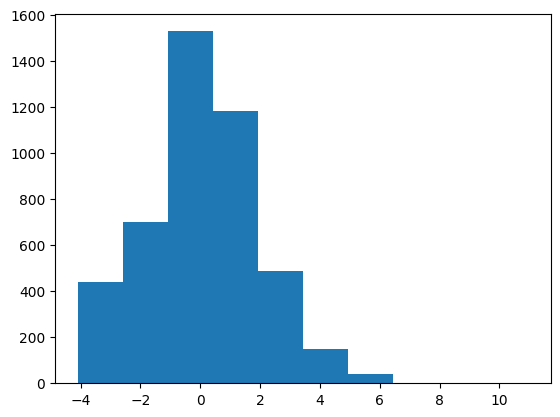

In [ ]:
import matplotlib.pyplot as plt
plt.hist(db_storico_centreback["DEFENSE_SCORE"])
plt.show()

In [ ]:
# DEFENSIVE EFFICENCY
features = [
      "duelsWon_percent",
      "defensiveDuelsWon_percent",
      "aerialDuelsWon_percent",
      "dribblesAgainstWon_percent",
      "pressingDuelsWon",
      "looseBallDuelsWon",
      "successfulSlidingTackles_percent"
  ]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc2 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["DEFENSE_EFFICIENCY"] = pc2

print(pca.explained_variance_ratio_)

                            feature    weight
0                  duelsWon_percent  0.611210
1         defensiveDuelsWon_percent  0.473766
2            aerialDuelsWon_percent  0.406892
5                 looseBallDuelsWon  0.359677
3        dribblesAgainstWon_percent  0.286666
6  successfulSlidingTackles_percent  0.157675
4                  pressingDuelsWon -0.000000
[0.30255253]


In [ ]:
db_storico_centreback["DEFENSE_EFFICIENCY"].describe()

,DEFENSE_EFFICIENCY
count,4.531000e+03
mean,1.881817e-17
std,1.347485e+00
min,-3.316314e+00
25%,-8.822092e-01
50%,1.007379e-02
75%,9.139168e-01
max,4.597414e+00


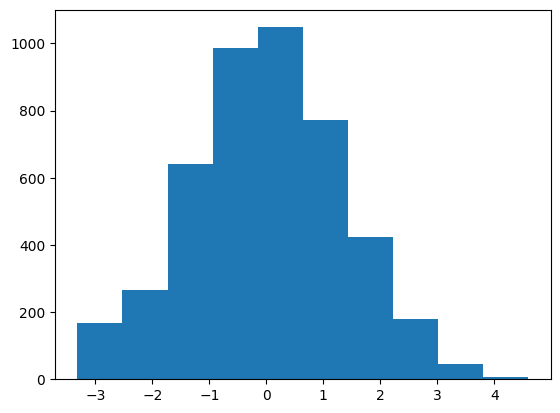

In [ ]:
import matplotlib.pyplot as plt
plt.hist(db_storico_centreback["DEFENSE_EFFICIENCY"])
plt.show()

In [ ]:
# BALL RECOVERY
features = [
      "interceptions",
      "ballRecoveries",
      "opponentHalfRecoveries",
      "dangerousOpponentHalfRecoveries",
      "counterpressingRecoveries"
  ]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc3 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["BALL_RECOVERY"] = pc3

print(pca.explained_variance_ratio_)

                           feature    weight
1                   ballRecoveries  0.562900
4        counterpressingRecoveries  0.533600
2           opponentHalfRecoveries  0.445711
0                    interceptions  0.362425
3  dangerousOpponentHalfRecoveries  0.261543
[0.50785364]


In [ ]:
# BALL LOSSES
features = [
    "losses",
    "ownHalfLosses",
    "ballLosses",
    "missedBalls",
    "dangerousOwnHalfLosses"
  ]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc4 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["BALL_LOSSES"] = pc4

print(pca.explained_variance_ratio_)

                  feature    weight
1           ownHalfLosses  0.621065
0                  losses  0.579813
4  dangerousOwnHalfLosses  0.483261
2              ballLosses  0.166760
3             missedBalls  0.129404
[0.4304412]


In [ ]:
# PLAYMAKING
features = [
    "passes",
    "forwardPasses",
    "backPasses",
    "verticalPasses",
    "longPasses",
    "passesToFinalThird",
    "crosses",
    "lateralPasses",
    "corners",
    "receivedPass"
  ]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc5 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["PLAYMAKING"] = pc5

print(pca.explained_variance_ratio_)

              feature    weight
0              passes  0.424627
9        receivedPass  0.411854
7       lateralPasses  0.373917
3      verticalPasses  0.373917
1       forwardPasses  0.367626
5  passesToFinalThird  0.323391
4          longPasses  0.246150
2          backPasses  0.220978
6             crosses  0.141068
8             corners  0.037267
[0.53401223]


In [ ]:
# PASSING EFFICENCY
features = [
    "successfulPasses_percent",
    "successfulForwardPasses_percent",
    "successfulBackPasses_percent",
    "successfulVerticalPasses_percent",
    "successfulLongPasses_percent",
    "successfulPassesToFinalThird_percent",
    "successfulCrosses_percent",
    "successfulLateralPasses_percent",
  ]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc6 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["PASSING_EFFICENCY"] = pc6

print(pca.explained_variance_ratio_)

                                feature    weight
0              successfulPasses_percent  0.434131
3      successfulVerticalPasses_percent  0.420689
7       successfulLateralPasses_percent  0.420689
1       successfulForwardPasses_percent  0.416358
5  successfulPassesToFinalThird_percent  0.313170
2          successfulBackPasses_percent  0.310650
4          successfulLongPasses_percent  0.293535
6             successfulCrosses_percent  0.058956
[0.63117819]


In [ ]:
# PASSING STYLE
features = [
    "passLength",
    "longPassLength"
  ]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc7 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["PASSING_STYLE"] = pc7

print(pca.explained_variance_ratio_)

          feature    weight
1  longPassLength  0.707107
0      passLength  0.707107
[0.70743344]


In [ ]:
# PROGRESSION
features = [
    "dribbles",
    "accelerations",
    "progressivePasses",
    "passesToFinalThird",
    "offensiveDuels",
    "dribbleDistanceFromOpponentGoal",
    "progressiveRun"
  ]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc8 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["PROGRESSION"] = pc8

print(pca.explained_variance_ratio_)

                           feature    weight
0                         dribbles  0.456965
4                   offensiveDuels  0.439899
2                progressivePasses  0.389577
3               passesToFinalThird  0.380543
5  dribbleDistanceFromOpponentGoal  0.363539
6                   progressiveRun  0.334669
1                    accelerations  0.238589
[0.38844955]


In [ ]:
# PROGRESSION_EFFICIENCY
features = [
      "successfulDribbles_percent",
      "successfulProgressivePasses_percent",
      "successfulPassesToFinalThird_percent",
      "offensiveDuelsWon_percent"
]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc9 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["PROGRESSION_EFFINCIENCY"] = pc9

print(pca.explained_variance_ratio_)

                                feature    weight
1   successfulProgressivePasses_percent  0.537105
2  successfulPassesToFinalThird_percent  0.524820
3             offensiveDuelsWon_percent  0.471369
0            successfulDribbles_percent  0.462486
[0.44366171]


In [ ]:
# FORWARD ACTIVITY
features = [
        "shots",
        "shotsOnTarget_percent",
        "headShots",
        "attackingActions",
        "xgShot",
        "touchInBox",
        "offsides",
        "linkupPlays",
        "penalties",
]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc10 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["FORWARD_ACTIVITY"] = pc10

print(pca.explained_variance_ratio_)

                 feature    weight
0                  shots  0.491140
4                 xgShot  0.436738
5             touchInBox  0.433143
2              headShots  0.422323
1  shotsOnTarget_percent  0.325457
3       attackingActions  0.307532
6               offsides  0.038269
7            linkupPlays  0.007329
8              penalties -0.007394
[0.38338814]


In [ ]:
# SHOOTING EFFICENCY
features = [
      "headShotsOnTarget_percent",
      "goalConversion_percent",
      "directFreeKicksOnTarget_percent",
      "goals",
      "successfulLinkupPlays_percent",
]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc11 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["SHOOTING_EFFICENCY"] = pc11

print(pca.explained_variance_ratio_)

                           feature    weight
3                            goals  0.636522
1           goalConversion_percent  0.631966
0        headShotsOnTarget_percent  0.441505
2  directFreeKicksOnTarget_percent  0.021906
4    successfulLinkupPlays_percent -0.007227
[0.4496114]


In [ ]:
# CHANCE CREATION
features = [
      "assists",
      "keyPasses",
      "shotAssists",
      "smartPasses",
      "throughPasses",
      "shotOnTargetAssists",
      "xgAssist",
      "secondAssists",
      "thirdAssists"
]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc12 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["CHANCE_CREATION"] = pc12

print(pca.explained_variance_ratio_)

               feature    weight
1            keyPasses  0.500360
5  shotOnTargetAssists  0.500360
6             xgAssist  0.452803
2          shotAssists  0.446002
0              assists  0.254854
4        throughPasses  0.147259
3          smartPasses  0.073642
7        secondAssists  0.056103
8         thirdAssists  0.011126
[0.37973871]


In [ ]:
# CHANCE EFFICENCY
features = [
      "successfulSmartPasses_percent",
      "successfulKeyPasses_percent",
      "successfulShotAssists_percent",
      "assists",
      "successfulThroughPasses_percent"
]


df_cb  = db_storico_centreback[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cb )

pca = PCA(n_components=1)
pc13 = pca.fit_transform(X_scaled)

loadings = pca.components_[0]

weights_df = pd.DataFrame({
    "feature": features,
    "weight": loadings
}).sort_values(by="weight", ascending=False)

print(weights_df)

db_storico_centreback["CHANCE_EFFICENCY"] = pc13

print(pca.explained_variance_ratio_)

                           feature    weight
1      successfulKeyPasses_percent  0.590377
2    successfulShotAssists_percent  0.553196
3                          assists  0.484734
4  successfulThroughPasses_percent  0.280178
0    successfulSmartPasses_percent  0.178781
[0.38375172]


In [ ]:
display(db_storico_centreback.head())

,playerId,competitionId,seasonId,positions,matchId,player_name,match_date,minutesOnField,goals,assists,...,BALL_LOSSES,PLAYMAKING,PASSING_EFFICENCY,PASSING_STYLE,PROGRESSION,PROGRESSION_EFFINCIENCY,FORWARD_ACTIVITY,SHOOTING_EFFICENCY,CHANCE_CREATION,CHANCE_EFFICENCY
48,422552,516,185942,"Defensive Midfielder, Centre Back",2782402,Enrico Del Prato,2019-01-11 14:30:00,96,0,1,...,-0.010476,0.802405,1.711152,-0.358628,0.563822,0.879543,-0.945654,-0.358626,10.262926,11.021720
50,422552,516,185942,"Defensive Midfielder, Centre Back",2782379,Enrico Del Prato,2018-12-07 14:30:00,96,1,0,...,0.650052,1.079539,1.057778,0.073079,0.728696,0.167339,4.078931,8.594015,2.648231,2.304765
551,548399,516,185942,Centre Back,2782400,Simone Canestrelli,2019-01-12 14:30:00,24,0,0,...,-2.378187,-4.385140,-6.899919,-1.725652,-2.138941,-2.562267,-1.253806,-0.358626,-0.524678,-0.391609
554,548399,516,185942,"Right Centre Back, Centre Back",2782365,Simone Canestrelli,2018-11-26 14:30:00,98,0,0,...,0.821886,2.935907,1.201133,0.698426,0.179662,-0.011418,1.780938,-0.358626,-0.524678,-0.391609
591,405603,516,181451,Centre Back,2602349,Matteo Gabbia,2018-05-06 11:00:00,96,0,0,...,0.006370,3.437869,1.188017,0.685670,-0.126037,-0.050271,2.221816,-0.358626,1.061777,2.304765


In [ ]:
# Select the first 8 columns
first_7_columns = db_storico_centreback.columns[:7]

# Select the last 13 columns (these are the PCA scores you've calculated)
last_14_columns = db_storico_centreback.columns[-14:]

# Combine the column names, ensuring no duplicates if there's overlap (though unlikely here)
columns_to_keep = list(first_7_columns) + list(last_14_columns)

# Filter the DataFrame to keep only these columns
db_storico_centreback_filtered = db_storico_centreback[columns_to_keep].copy()

print(f"New DataFrame has {db_storico_centreback_filtered.shape[1]} columns.")
display(db_storico_centreback_filtered.head())

New DataFrame has 21 columns.


,playerId,competitionId,seasonId,matchId,player_name,match_date,minutesOnField,positions,DEFENSE_SCORE,DEFENSE_EFFICIENCY,...,BALL_LOSSES,PLAYMAKING,PASSING_EFFICENCY,PASSING_STYLE,PROGRESSION,PROGRESSION_EFFINCIENCY,FORWARD_ACTIVITY,SHOOTING_EFFICENCY,CHANCE_CREATION,CHANCE_EFFICENCY
129,475430,516,185942,2782684,Alessandro Zanoli,2019-05-18 11:00:00,94,CentreBack,-0.098250,-1.709641,...,0.105790,-1.471460,-0.669390,-0.000616,3.067055,0.788779,-0.564304,-0.350211,-0.668754,-0.522441
130,475430,516,185942,2782672,Alessandro Zanoli,2019-05-10 15:00:00,99,CentreBack,-0.113843,1.893804,...,0.777380,0.312807,-0.301565,1.281224,2.593600,0.028955,-0.908076,-0.350211,-0.342974,-0.522441
131,475430,516,185942,2782667,Alessandro Zanoli,2019-05-04 14:30:00,92,CentreBack,-1.952903,-0.434372,...,-0.571749,-1.502629,1.955873,2.303244,0.582476,0.458621,-1.219352,-0.350211,-0.493334,0.571163
132,475430,516,185942,2782647,Alessandro Zanoli,2019-04-24 14:00:00,93,CentreBack,2.139029,0.376345,...,1.857987,-0.468211,0.490046,0.146924,1.450504,-0.196754,-0.225632,-0.350211,-0.668754,-0.522441
134,475430,516,185942,2782636,Alessandro Zanoli,2019-03-30 11:00:00,95,CentreBack,1.136801,0.183800,...,1.800055,-0.498620,0.454772,0.859325,-1.376149,-1.249903,0.567558,-0.350211,-0.498704,-0.522441


In [ ]:
ranking_storico_centreback = db_storico_centreback.groupby("player_name").agg({
    "DEFENSE_SCORE": "mean",
    "DEFENSE_EFFICIENCY": "mean",
    "BALL_RECOVERY": "mean",
    "PLAYMAKING": "mean",
    "minutesOnField": "sum"
})

ranking_storico_centreback = ranking_storico_centreback[ranking_storico_centreback["minutesOnField"] > 4500] # giocatori con almeno 50 partite

ranking_storico_centreback.sort_values("DEFENSE_SCORE", ascending=False)

,DEFENSE_SCORE,DEFENSE_EFFICIENCY,BALL_RECOVERY,PLAYMAKING,minutesOnField
player_name,,,,,
Giorgio Scalvini,0.752248,0.093542,0.684918,0.746033,10663
Alberto Dossena,0.666094,0.508887,0.597294,-0.850687,17778
Alessandro Buongiorno,0.624596,0.483934,0.375660,-0.692296,16869
Gianluca Mancini,0.560901,0.319112,0.109161,0.599594,26177
Matteo Bianchetti,0.529925,0.155709,0.434927,0.047005,23544
Adam Obert,0.412233,-0.229215,-0.040746,0.740832,7684
Arturo Calabresi,0.386124,-0.296258,0.031272,-0.622668,9423
Nicolò Casale,0.279461,-0.060739,0.350788,-0.196847,18168
Marin Pongračić,0.194001,0.369050,0.078133,0.077067,8480


# AUTOMATIZZAZIONE PCA

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def analyze_position_group(position_group, source_df, min_minutes=3000):
    print(f"\n--- Analyzing position group: {position_group} ---")

    db_group_analysis = source_df[source_df['positions'] == position_group].copy()

    if db_group_analysis.empty:
        print(f"No players found for position group '{position_group}'.")
        return pd.DataFrame(), pd.DataFrame() # Return empty DataFrames

    print(f"Found {len(db_group_analysis)} entries for {position_group} players.")

    # Define feature sets for each PCA component
    pca_definitions = {
        "DEFENSE_SCORE": [
            "duels", "defensiveDuels", "aerialDuels", "looseBallDuels",
            "pressingDuels", "defensiveActions", "fouls", "clearances",
            "slidingTackles", "shotsBlocked", "dribblesAgainst"
        ],
        "DEFENSE_EFFICIENCY": [
            "duelsWon_percent", "defensiveDuelsWon_percent", "aerialDuelsWon_percent",
            "dribblesAgainstWon_percent", "pressingDuelsWon", "looseBallDuelsWon",
            "successfulSlidingTackles_percent"
        ],
        "BALL_RECOVERY": [
            "interceptions", "ballRecoveries", "opponentHalfRecoveries",
            "dangerousOpponentHalfRecoveries", "counterpressingRecoveries"
        ],
        "BALL_LOSSES": [
            "losses", "ownHalfLosses", "ballLosses", "missedBalls", "dangerousOwnHalfLosses"
        ],
        "PLAYMAKING": [
            "passes", "forwardPasses", "backPasses", "verticalPasses",
            "longPasses", "passesToFinalThird", "crosses", "lateralPasses",
            "corners", "receivedPass"
        ],
        "PASSING_EFFICENCY": [
            "successfulPasses_percent", "successfulForwardPasses_percent",
            "successfulBackPasses_percent", "successfulVerticalPasses_percent",
            "successfulLongPasses_percent", "successfulPassesToFinalThird_percent",
            "successfulCrosses_percent", "successfulLateralPasses_percent"
        ],
        "PASSING_STYLE": [
            "passLength", "longPassLength"
        ],
        "PROGRESSION": [
            "dribbles", "accelerations", "progressivePasses", "passesToFinalThird",
            "offensiveDuels", "dribbleDistanceFromOpponentGoal", "progressiveRun"
        ],
        "PROGRESSION_EFFICIENCY": [
            "successfulDribbles_percent", "successfulProgressivePasses_percent",
            "successfulPassesToFinalThird_percent", "offensiveDuelsWon_percent"
        ],
        "FORWARD_ACTIVITY": [
            "shots", "shotsOnTarget_percent", "headShots", "attackingActions",
            "xgShot", "touchInBox", "offsides", "linkupPlays", "penalties"
        ],
        "SHOOTING_EFFICENCY": [
            "headShotsOnTarget_percent", "goalConversion_percent",
            "directFreeKicksOnTarget_percent", "goals", "successfulLinkupPlays_percent"
        ],
        "CHANCE_CREATION": [
            "assists", "keyPasses", "shotAssists", "smartPasses",
            "throughPasses", "shotOnTargetAssists", "xgAssist",
            "secondAssists", "thirdAssists"
        ],
        "CHANCE_EFFICENCY": [
            "successfulSmartPasses_percent", "successfulKeyPasses_percent",
            "successfulShotAssists_percent", "assists", "successfulThroughPasses_percent"
        ]
    }

    for score_name, features_list in pca_definitions.items():
        print(f"\n--- Calculating {score_name} ---")
        # Ensure all features exist in the DataFrame
        existing_features = [f for f in features_list if f in db_group_analysis.columns]
        if not existing_features:
            print(f"  Warning: None of the features for {score_name} found in DataFrame. Skipping.")
            continue

        df_features = db_group_analysis[existing_features].fillna(0)

        if df_features.empty or df_features.std().sum() == 0: # Check for all-zero columns after fillna
            print(f"  Warning: No meaningful data or zero variance for features in {score_name}. Skipping PCA.")
            db_group_analysis[score_name] = 0 # Assign a default value if PCA cannot be run
            continue

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df_features)

        pca = PCA(n_components=1)
        pc_score = pca.fit_transform(X_scaled)

        loadings = pca.components_[0]
        weights_df = pd.DataFrame({
            "feature": existing_features,
            "weight": loadings
        }).sort_values(by="weight", ascending=False)

        print("  Feature Weights (Loadings):")
        print(weights_df)
        print(f"  Explained Variance Ratio: {pca.explained_variance_ratio_[0]:.4f}")

        db_group_analysis[score_name] = pc_score

    # --- Final Ranking ---
    print(f"\n--- Generating Ranking for {position_group} ---")

    # Include all calculated PCA scores and minutesOnField for aggregation
    # Filter for columns that actually exist in db_group_analysis
    pca_score_cols_to_agg = [score_name for score_name in pca_definitions.keys() if score_name in db_group_analysis.columns]
    agg_dict = {score_name: "mean" for score_name in pca_score_cols_to_agg}
    agg_dict["minutesOnField"] = "sum"

    ranking_df = db_group_analysis.groupby("player_name").agg(agg_dict)

    # Filter by minimum minutes played
    ranking_df = ranking_df[ranking_df["minutesOnField"] > min_minutes]

    # Sort by DEFENSE_SCORE (or any other relevant score)
    if 'DEFENSE_SCORE' in ranking_df.columns:
        ranking_df = ranking_df.sort_values("DEFENSE_SCORE", ascending=False)
    elif ranking_df.columns.intersection(pca_definitions.keys()).any():
        # If DEFENSE_SCORE not available, sort by the first available PCA score
        first_pca_score = ranking_df.columns.intersection(pca_definitions.keys())[0]
        ranking_df = ranking_df.sort_values(first_pca_score, ascending=False)

    if ranking_df.empty:
        print(f"No players in '{position_group}' met the minimum minutesPlayed ({min_minutes}).")
    else:
        print(f"Ranking for {position_group} (min {min_minutes} minutes played):")
        display(ranking_df)

    # Prepare match_level_pca_df to return
    # Select only relevant columns for the match-level PCA scores
    match_level_cols = ['playerId', 'player_name', 'match_date', 'minutesOnField'] + pca_score_cols_to_agg
    match_level_pca_df = db_group_analysis[match_level_cols].copy()

    return ranking_df, match_level_pca_df

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/db_storico_match_TIDY.pkl', 'rb') as f:
    db_storico_match = pickle.load(f)

# GRAFICO RADAR PER PROFILAZIONE

In [ ]:
import plotly.express as px
import pandas as pd

def give_me_profile(ranking_df, title="Player Performance Profiles (PCA Scores)"):
    """
    Generates an interactive radar chart for player performance profiles from a ranking DataFrame.

    Args:
        ranking_df (pd.DataFrame): DataFrame containing player rankings and PCA scores.
                                   Expected to have 'player_name' as index or a column.
        title (str): Title for the radar chart.
    """
    # Reset index to make 'player_name' a regular column for plotting
    df_plot = ranking_df.reset_index()

    # Select the columns for the radar chart
    # Exclude 'minutesOnField' as it's not a performance score in the same sense
    plot_columns = [
        'player_name',
        'DEFENSE_SCORE',
        'DEFENSE_EFFICIENCY',
        'BALL_RECOVERY',
        'BALL_LOSSES',
        'PLAYMAKING',
        'PASSING_EFFICENCY',
        'PASSING_STYLE',
        'PROGRESSION',
        'PROGRESSION_EFFICIENCY',
        'FORWARD_ACTIVITY',
        'SHOOTING_EFFICENCY',
        'CHANCE_CREATION',
        'CHANCE_EFFICENCY'
    ]

    # Filter plot_columns to only include those present in df_plot
    actual_plot_columns = [col for col in plot_columns if col in df_plot.columns]

    df_radar = df_plot[actual_plot_columns]

    # Melt the DataFrame to long format for Plotly Express radar chart
    df_melted = df_radar.melt(
        id_vars=['player_name'],
        var_name='Metric',
        value_name='Score'
    )

    # Create the radar chart
    fig = px.line_polar(
        df_melted,
        r='Score',
        theta='Metric',
        color='player_name',
        line_close=True,
        title=title,
        template='plotly_white',
        hover_name='player_name',
        labels={'Score': 'PCA Score', 'Metric': 'Performance Metric'}
    )

    fig.update_traces(fill='toself')
    fig.show()

print("Function 'give_me_profile' created.")

Function 'give_me_profile' created.


In [ ]:
# --- Step 3: Visualize rankings (if any were created) ---
if player_rankings_by_position:
    print("\n--- Visualizing Player Performance Profiles (Radar Charts) ---")
    for position, ranking_df in player_rankings_by_position.items():
        # Ensure there are enough players in the ranking_df to visualize meaningfully
        if not ranking_df.empty:
            give_me_profile(ranking_df, title=f'{position} Player Performance Profiles (PCA Scores)')
        else:
            print(f"No players in {position} ranking to visualize.")
else:
    print("\nNo player rankings available to visualize.")

NameError: name 'player_rankings_by_position' is not defined

# 24/03

creo un db con tutte stats di tutte le partite di tutti i giocatori nati dal 2003

In [ ]:
import pickle
import pandas as pd


with open('/content/drive/MyDrive/Colab Notebooks/players_df.pkl', 'rb') as f:
    players_df = pickle.load(f)

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/db_young_match.pkl', 'rb') as f:
    db_young_match = pickle.load(f)

In [ ]:
players_df['birth_date'] = pd.to_datetime(players_df['birth_date'])
cutoff_date = pd.to_datetime('2004-01-01')

young_players_df = players_df[players_df['birth_date'] >= cutoff_date].copy()
young_players_df = young_players_df[young_players_df['role'] != 'Goalkeeper'].copy()

print(f"Original players_df size: {len(players_df)}")
print(f"Players born on or after 2004-01-01 (excluding Goalkeepers): {len(young_players_df)}")
display(young_players_df.head())

Original players_df size: 2893
Players born on or after 2004-01-01 (excluding Goalkeepers): 793


,name,wyId,team_name,birth_date,role
19,Davide Bartesaghi,632175,Milan,2005-12-29,Defender
21,David Odogu,764770,Milan,2006-06-03,Defender
22,Mattia Piermarini,784677,Milan,2006-03-13,Defender
23,Zachary Athekame,876427,Milan,2004-12-13,Defender
41,Evan Ferguson,616591,Roma,2004-10-19,Forward


In [ ]:
young_player_wyIds = young_players_df['wyId'].tolist()
print(f"Number of young player WyIds: {len(young_player_wyIds)}")

Number of young player WyIds: 793


In [ ]:
# creo il db con tutte le stats delle partite dei young players

target_season_id = 185942

df_statsBYmatchYoung = get_player_seasonal_match_stats(young_player_wyIds, target_season_id, young_players_df)

Starting to fetch match advanced stats for 793 players for season 185942...


Processing Players:  38%|███▊      | 301/793 [01:19<02:34,  3.18it/s]

Processing Players:  44%|████▍     | 348/793 [01:33<01:57,  3.80it/s]

Processing Players: 100%|██████████| 793/793 [03:32<00:00,  3.73it/s]


Collected advanced stats for 0 player-match combinations.
DataFrame of players' season match advanced stats created.


In [ ]:
db_young_match = pd.concat([df_statsBYmatchYoung, db_young_match], ignore_index=True)
print(f"db_young_match aggiornato, match totali presenti: {len(db_young_match)}")

db_young_match aggiornato, match totali presenti: 48066


In [ ]:
print("Unique season IDs and their counts in db_young_match:")
display(db_young_match['seasonId'].value_counts())

Unique season IDs and their counts in db_young_match:


,count
seasonId,
191772,12249
190261,7334
189187,5053
190170,4274
188325,4154
189262,3198
191771,2535
191623,1778
190084,1554


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/db_young_match.pkl"
db_young_match.to_pickle(file_path)

# 26/03

In [ ]:
import pickle
import pandas as pd


with open('/content/drive/MyDrive/Colab Notebooks/db_storico_match_TIDY.pkl', 'rb') as f:
    db_storico_match = pickle.load(f)

with open('/content/drive/MyDrive/Colab Notebooks/db_young_match.pkl', 'rb') as f:
    db_young_match = pickle.load(f)

In [ ]:
db_young_match = db_young_match.drop(columns=['roundId', 'player_wyId', 'match_wyId', 'match_label'])
print("Columns 'roundId', 'player_wyId', 'match_wyId', and 'match_label' removed from db_young_match.")
display(db_young_match.head())

Columns 'roundId', 'player_wyId', 'match_wyId', and 'match_label' removed from db_young_match.


,playerId,competitionId,seasonId,positions,total,average,percent,matchId,player_name,match_date
0,728835,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158965,Gvidas Gineitis,2021-06-09 19:00:00
1,632957,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158748,Alessandro Dellavalle,2020-09-21 11:00:00
2,625383,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158932,Lorenzo Ignacchiti,2021-05-22 15:00:00
3,625385,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158988,Gabriele Indragoli,2021-06-30 18:30:00
4,625385,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5228587,Gabriele Indragoli,2021-06-23 19:00:00


In [ ]:
def extract_selected_total_stats(total_stats_dict):
    if not isinstance(total_stats_dict, dict):
        return {}

    selected_stats = {
        'minutesOnField': total_stats_dict.get('minutesOnField', 0),
        'goals': total_stats_dict.get('goals', 0),
        'assists': total_stats_dict.get('assists', 0),
        'yellowCards': total_stats_dict.get('yellowCards', 0),
        'redCards': total_stats_dict.get('redCards', 0),
        'penalties': total_stats_dict.get('penalties', 0),
        'corners': total_stats_dict.get('corners', 0),
        'pressingDuels': total_stats_dict.get('pressingDuels', 0),
        'pressingDuelsWon': total_stats_dict.get('pressingDuelsWon', 0)
    }
    return selected_stats

# Apply the function to the 'total' column and create new columns
extracted_stats_df_young = db_young_match['total'].apply(extract_selected_total_stats).apply(pd.Series)

# Concatenate the new columns with the original DataFrame
db_young_match = pd.concat([db_young_match, extracted_stats_df_young], axis=1)

print("Extracted selected statistics from 'total' column and added them to db_young_match.")
display(db_young_match.head())

Extracted selected statistics from 'total' column and added them to db_young_match.


,playerId,competitionId,seasonId,positions,total,average,percent,matchId,player_name,match_date,minutesOnField,goals,assists,yellowCards,redCards,penalties,corners,pressingDuels,pressingDuelsWon
0,728835,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158965,Gvidas Gineitis,2021-06-09 19:00:00,0,0,0,0,0,0,0,0,0
1,632957,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158748,Alessandro Dellavalle,2020-09-21 11:00:00,0,0,0,0,0,0,0,0,0
2,625383,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158932,Lorenzo Ignacchiti,2021-05-22 15:00:00,0,0,0,0,0,0,0,0,0
3,625385,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158988,Gabriele Indragoli,2021-06-30 18:30:00,0,0,0,0,0,0,0,0,0
4,625385,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5228587,Gabriele Indragoli,2021-06-23 19:00:00,0,0,0,0,0,0,0,0,0


In [ ]:
def extract_selected_average_stats(average_stats_dict):
    if not isinstance(average_stats_dict, dict):
        return {}

    selected_stats = {
        'passLength': average_stats_dict.get('passLength', 0),
        'longPassLength': average_stats_dict.get('longPassLength', 0),
        'dribbleDistanceFromOpponentGoal': average_stats_dict.get('dribbleDistanceFromOpponentGoal', 0),
        'ballRecoveries': average_stats_dict.get('ballRecoveries', 0),
        'duels': average_stats_dict.get('duels', 0),
        'defensiveDuels': average_stats_dict.get('defensiveDuels', 0),
        'offensiveDuels': average_stats_dict.get('offensiveDuels', 0),
        'aerialDuels': average_stats_dict.get('aerialDuels', 0),
        'fouls': average_stats_dict.get('fouls', 0),
        'goals_avg': average_stats_dict.get('goals', 0), # Renamed to avoid collision if 'goals' from 'total' is kept
        'assists_avg': average_stats_dict.get('assists', 0), # Renamed
        'passes': average_stats_dict.get('passes', 0),
        'smartPasses': average_stats_dict.get('smartPasses', 0),
        'passesToFinalThird': average_stats_dict.get('passesToFinalThird', 0),
        'crosses': average_stats_dict.get('crosses', 0),
        'dribbles': average_stats_dict.get('dribbles', 0),
        'shots': average_stats_dict.get('shots', 0),
        'headShots': average_stats_dict.get('headShots', 0),
        'interceptions': average_stats_dict.get('interceptions', 0),
        'accelerations': average_stats_dict.get('accelerations', 0),
        'looseBallDuels': average_stats_dict.get('looseBallDuels', 0),
        'missedBalls': average_stats_dict.get('missedBalls', 0),
        'forwardPasses': average_stats_dict.get('forwardPasses', 0),
        'backPasses': average_stats_dict.get('backPasses', 0),
        'throughPasses': average_stats_dict.get('throughPasses', 0),
        'keyPasses': average_stats_dict.get('keyPasses', 0),
        'verticalPasses': average_stats_dict.get('verticalPasses', 0),
        'longPasses': average_stats_dict.get('longPasses', 0),
        'shotAssists': average_stats_dict.get('shotAssists', 0),
        'shotOnTargetAssists': average_stats_dict.get('shotOnTargetAssists', 0),
        'linkupPlays': average_stats_dict.get('linkupPlays', 0),
        'opponentHalfRecoveries': average_stats_dict.get('opponentHalfRecoveries', 0),
        'dangerousOpponentHalfRecoveries': average_stats_dict.get('dangerousOpponentHalfRecoveries', 0),
        'ballLosses': average_stats_dict.get('ballLosses', 0),
        'losses': average_stats_dict.get('losses', 0),
        'ownHalfLosses': average_stats_dict.get('ownHalfLosses', 0),
        'dangerousOwnHalfLosses': average_stats_dict.get('dangerousOwnHalfLosses', 0),
        'defensiveActions': average_stats_dict.get('defensiveActions', 0),
        'attackingActions': average_stats_dict.get('attackingActions', 0),
        'looseBallDuelsWon': average_stats_dict.get('looseBallDuelsWon', 0),
        'xgShot': average_stats_dict.get('xgShot', 0),
        'xgAssist': average_stats_dict.get('xgAssist', 0),
        'receivedPass': average_stats_dict.get('receivedPass', 0),
        'touchInBox': average_stats_dict.get('touchInBox', 0),
        'progressiveRun': average_stats_dict.get('progressiveRun', 0),
        'offsides': average_stats_dict.get('offsides', 0),
        'clearances': average_stats_dict.get('clearances', 0),
        'secondAssists': average_stats_dict.get('secondAssists', 0),
        'thirdAssists': average_stats_dict.get('thirdAssists', 0),
        'foulsSuffered': average_stats_dict.get('foulsSuffered', 0),
        'progressivePasses': average_stats_dict.get('progressivePasses', 0),
        'counterpressingRecoveries': average_stats_dict.get('counterpressingRecoveries', 0),
        'slidingTackles': average_stats_dict.get('slidingTackles', 0),
        'shotsBlocked': average_stats_dict.get('shotsBlocked', 0),
        'dribblesAgainst': average_stats_dict.get('dribblesAgainst', 0),
        'lateralPasses': average_stats_dict.get('lateralPasses', 0)
    }
    return selected_stats

# Apply the function to the 'average' column and create new columns
extracted_average_stats_df_young = db_young_match['average'].apply(extract_selected_average_stats).apply(pd.Series)

# Concatenate the new columns with the original DataFrame
db_young_match = pd.concat([db_young_match, extracted_average_stats_df_young], axis=1)

print("Extracted selected statistics from 'average' column and added them to db_young_match.")
display(db_young_match.head())

Extracted selected statistics from 'average' column and added them to db_young_match.


,playerId,competitionId,seasonId,positions,total,average,percent,matchId,player_name,match_date,...,clearances,secondAssists,thirdAssists,foulsSuffered,progressivePasses,counterpressingRecoveries,slidingTackles,shotsBlocked,dribblesAgainst,lateralPasses
0,728835,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158965,Gvidas Gineitis,2021-06-09 19:00:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,632957,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158748,Alessandro Dellavalle,2020-09-21 11:00:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,625383,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158932,Lorenzo Ignacchiti,2021-05-22 15:00:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,625385,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5158988,Gabriele Indragoli,2021-06-30 18:30:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,625385,516,186517,[],"{'matches': 0, 'matchesInStart': 0, 'matchesSu...","{'passLength': 0, 'longPassLength': 0, 'dribbl...","{'duelsWon': 0, 'defensiveDuelsWon': 0, 'offen...",5228587,Gabriele Indragoli,2021-06-23 19:00:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
def extract_selected_percent_stats(percent_stats_dict):
    if not isinstance(percent_stats_dict, dict):
        return {}

    selected_stats = {
        'duelsWon_percent': percent_stats_dict.get('duelsWon', 0),
        'defensiveDuelsWon_percent': percent_stats_dict.get('defensiveDuelsWon', 0),
        'offensiveDuelsWon_percent': percent_stats_dict.get('offensiveDuelsWon', 0),
        'aerialDuelsWon_percent': percent_stats_dict.get('aerialDuelsWon', 0),
        'successfulPasses_percent': percent_stats_dict.get('successfulPasses', 0),
        'successfulSmartPasses_percent': percent_stats_dict.get('successfulSmartPasses', 0),
        'successfulPassesToFinalThird_percent': percent_stats_dict.get('successfulPassesToFinalThird', 0),
        'successfulCrosses_percent': percent_stats_dict.get('successfulCrosses', 0),
        'successfulDribbles_percent': percent_stats_dict.get('successfulDribbles', 0),
        'shotsOnTarget_percent': percent_stats_dict.get('shotsOnTarget', 0),
        'headShotsOnTarget_percent': percent_stats_dict.get('headShotsOnTarget', 0),
        'goalConversion_percent': percent_stats_dict.get('goalConversion', 0),
        'directFreeKicksOnTarget_percent': percent_stats_dict.get('directFreeKicksOnTarget', 0),
        'successfulForwardPasses_percent': percent_stats_dict.get('successfulForwardPasses', 0),
        'successfulBackPasses_percent': percent_stats_dict.get('successfulBackPasses', 0),
        'successfulThroughPasses_percent': percent_stats_dict.get('successfulThroughPasses', 0),
        'successfulKeyPasses_percent': percent_stats_dict.get('successfulKeyPasses', 0),
        'successfulVerticalPasses_percent': percent_stats_dict.get('successfulVerticalPasses', 0),
        'successfulLongPasses_percent': percent_stats_dict.get('successfulLongPasses', 0),
        'successfulShotAssists_percent': percent_stats_dict.get('successfulShotAssists', 0),
        'successfulLinkupPlays_percent': percent_stats_dict.get('successfulLinkupPlays', 0),
        'yellowCardsPerFoul_percent': percent_stats_dict.get('yellowCardsPerFoul', 0),
        'successfulProgressivePasses_percent': percent_stats_dict.get('successfulProgressivePasses', 0),
        'successfulSlidingTackles_percent': percent_stats_dict.get('successfulSlidingTackles', 0),
        'dribblesAgainstWon_percent': percent_stats_dict.get('dribblesAgainstWon', 0),
        'successfulLateralPasses_percent': percent_stats_dict.get('successfulLateralPasses', 0)
    }
    return selected_stats

# Apply the function to the 'percent' column and create new columns
extracted_percent_stats_df_young = db_young_match['percent'].apply(extract_selected_percent_stats).apply(pd.Series)

# Concatenate the new columns with the original DataFrame
db_young_match = pd.concat([db_young_match, extracted_percent_stats_df_young], axis=1)


In [ ]:
db_young_match = db_young_match.drop(columns=['total', 'average', 'percent'])

print("Original 'total', 'average', and 'percent' columns dropped from db_young_match.")
display(db_young_match.head())

Original 'total', 'average', and 'percent' columns dropped from db_young_match.


,playerId,competitionId,seasonId,positions,matchId,player_name,match_date,minutesOnField,goals,assists,...,successfulKeyPasses_percent,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent
0,728835,516,186517,[],5158965,Gvidas Gineitis,2021-06-09 19:00:00,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,632957,516,186517,[],5158748,Alessandro Dellavalle,2020-09-21 11:00:00,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,625383,516,186517,[],5158932,Lorenzo Ignacchiti,2021-05-22 15:00:00,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,625385,516,186517,[],5158988,Gabriele Indragoli,2021-06-30 18:30:00,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,625385,516,186517,[],5228587,Gabriele Indragoli,2021-06-23 19:00:00,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/db_young_match_exploded.pkl"
db_young_match.to_pickle(file_path)

print(f"db_young_match saved to {file_path}")

db_young_match saved to /content/drive/MyDrive/Colab Notebooks/db_young_match_exploded.pkl


# 28/03

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/db_young_match_exploded.pkl', 'rb') as f:
    db_young_match = pickle.load(f)

In [ ]:
initial_rows = len(db_young_match)
db_young_match = db_young_match[db_young_match['minutesOnField'] >= 10].copy()
final_rows = len(db_young_match)
print(f"Original rows: {initial_rows}")
print(f"Rows after filtering minutesOnField >= 10: {final_rows}")
print(f"Removed {initial_rows - final_rows} rows where minutesOnField was less than 10.")
display(db_young_match.head())

Original rows: 48066
Rows after filtering minutesOnField >= 10: 29982
Removed 18084 rows where minutesOnField was less than 10.


,playerId,competitionId,seasonId,positions,matchId,player_name,match_date,minutesOnField,goals,assists,...,successfulKeyPasses_percent,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent
12,625385,516,186517,"[{'position': {'name': 'Left Centre Back', 'co...",5158913,Gabriele Indragoli,2021-05-08 17:00:00,15,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25,630926,516,186517,"[{'position': {'name': 'Right Winger', 'code':...",5158914,Costantino Favasuli,2021-05-09 10:30:00,33,0,0,...,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
26,630926,516,186517,"[{'position': {'name': 'Right Wingback', 'code...",5158905,Costantino Favasuli,2021-05-03 17:00:00,23,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,630926,516,186517,"[{'position': {'name': 'Left Wingback', 'code'...",5158853,Costantino Favasuli,2021-03-09 15:00:00,27,0,0,...,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
36,624104,516,186517,[{'position': {'name': 'Right Centre Midfielde...,5158951,Luca D'Andrea,2021-06-04 19:00:00,14,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
display(db_young_match.head())

,playerId,competitionId,seasonId,positions,matchId,player_name,match_date,minutesOnField,goals,assists,...,successfulKeyPasses_percent,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent
12,625385,516,186517,"[{'position': {'name': 'Left Centre Back', 'co...",5158913,Gabriele Indragoli,2021-05-08 17:00:00,15,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25,630926,516,186517,"[{'position': {'name': 'Right Winger', 'code':...",5158914,Costantino Favasuli,2021-05-09 10:30:00,33,0,0,...,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
26,630926,516,186517,"[{'position': {'name': 'Right Wingback', 'code...",5158905,Costantino Favasuli,2021-05-03 17:00:00,23,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,630926,516,186517,"[{'position': {'name': 'Left Wingback', 'code'...",5158853,Costantino Favasuli,2021-03-09 15:00:00,27,0,0,...,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
36,624104,516,186517,[{'position': {'name': 'Right Centre Midfielde...,5158951,Luca D'Andrea,2021-06-04 19:00:00,14,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import pandas as pd
import plotly.express as px

# Function to extract all position names (re-defined from cell 'aed2fefd' for clarity, or ensured it's available)
def get_all_position_names(positions_list):
    if positions_list and isinstance(positions_list, list):
        position_names = []
        for position_data in positions_list:
            if isinstance(position_data, dict) and 'position' in position_data:
                position_name = position_data['position'].get('name')
                if position_name:
                    position_names.append(position_name)
        return ', '.join(position_names) if position_names else None
    return None # Return None if no valid positions are found

# Apply the function to the 'positions' column of db_young_match first
db_young_match['positions'] = db_young_match['positions'].apply(get_all_position_names)

# Define a mapping from detailed positions to generalized roles based on user's new specification
position_mapping = {
    'Goalkeeper': 'Goalkeeper',

    'Left Back (5 at the back)': 'FullBack',
    'Left Back': 'FullBack',
    'Right Back': 'FullBack',
    'Right Back (5 at the back)': 'FullBack',

    'Centre Back': 'CentreBack',
    'Left Centre Back': 'CentreBack',
    'Left Centre Back (3 at the back)': 'CentreBack',
    'Right Centre Back': 'CentreBack',
    'Right Centre Back (3 at the back)': 'CentreBack',

    'Defensive Midfielder': 'DefensiveMidfielder',
    'Left Defensive Midfielder': 'DefensiveMidfielder',
    'Right Defensive Midfielder': 'DefensiveMidfielder',

    'Left Centre Midfielder': 'Midfielder',
    'Right Centre Midfielder': 'Midfielder',

    'Attacking Midfielder': 'AttackingMidfielder',
    'Left Attacking Midfielder': 'AttackingMidfielder',
    'Right Attacking Midfielder': 'AttackingMidfielder',

    'Left Wingback': 'WideMidfielder',
    'Right Wingback': 'WideMidfielder',

    'Left Winger': 'Winger',
    'Left Wing Forward': 'Winger',
    'Right Winger': 'Winger',
    'Right Wing Forward': 'Winger',

    'Striker': 'Striker'
}

# Function to map detailed positions to generalized roles
def get_generalized_position(positions_str):
    if pd.isna(positions_str) or not isinstance(positions_str, str):
        return 'Unknown'

    # Split the comma-separated string
    individual_positions = [p.strip() for p in positions_str.split(', ')]

    # Try to map each individual position to a generalized role
    generalized_roles = []
    for p in individual_positions:
        if p in position_mapping:
            generalized_roles.append(position_mapping[p])
        else:
            generalized_roles.append('Unknown') # Handle positions not in the new mapping

    # If there are multiple generalized roles, for simplicity, we'll take the first one.
    # More complex logic could be implemented if a hierarchy is preferred.
    if generalized_roles:
        return generalized_roles[0]
    return 'Unknown'

# Apply the function to create the new 'generalized_position' column
db_young_match['generalized_position'] = db_young_match['positions'].apply(get_generalized_position)

print("Generalized positions created with the new mapping.")
display(db_young_match.head())

Generalized positions created with the new mapping.


,playerId,competitionId,seasonId,positions,matchId,player_name,match_date,minutesOnField,goals,assists,...,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent,generalized_position
12,625385,516,186517,Left Centre Back,5158913,Gabriele Indragoli,2021-05-08 17:00:00,15,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CentreBack
25,630926,516,186517,"Right Winger, Right Wingback",5158914,Costantino Favasuli,2021-05-09 10:30:00,33,0,0,...,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,Winger
26,630926,516,186517,Right Wingback,5158905,Costantino Favasuli,2021-05-03 17:00:00,23,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WideMidfielder
29,630926,516,186517,Left Wingback,5158853,Costantino Favasuli,2021-03-09 15:00:00,27,0,0,...,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,WideMidfielder
36,624104,516,186517,Right Centre Midfielder,5158951,Luca D'Andrea,2021-06-04 19:00:00,14,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder


In [ ]:
db_young_match = db_young_match.drop(columns=['positions'])
db_young_match = db_young_match.rename(columns={'generalized_position': 'positions'})

In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/db_young_match_TIDY.pkl"
db_young_match.to_pickle(file_path)

print(f"db_young_match saved to {file_path}")

db_young_match saved to /content/drive/MyDrive/Colab Notebooks/db_young_match_TIDY.pkl


In [ ]:
import pandas as pd
import pickle

# Load players_df to get birth dates
with open('/content/drive/MyDrive/Colab Notebooks/players_df.pkl', 'rb') as f:
    players_df = pickle.load(f)

# Ensure birth_date is in datetime format in players_df
players_df['birth_date'] = pd.to_datetime(players_df['birth_date'])

print("players_df loaded and birth_date converted.")
display(players_df.head())

players_df loaded and birth_date converted.


,name,wyId,team_name,birth_date,role
0,Luka Modrić,8287,Milan,1985-09-09,Midfielder
1,Niclas Füllkrug,14705,Milan,1993-02-09,Forward
2,Pietro Terracciano,21065,Milan,1990-03-08,Goalkeeper
3,Mike Maignan,134496,Milan,1995-07-03,Goalkeeper
4,Adrien Rabiot,209117,Milan,1995-04-03,Midfielder


Adding birth_date and age to db_storico_match



---



In [ ]:
# Merge db_storico_match with players_df to get birth_date
db_storico_match = pd.merge(
    db_storico_match,
    players_df[['wyId', 'birth_date']],
    left_on='playerId',
    right_on='wyId',
    how='left'
)

# Drop the redundant 'wyId' column from the merge
db_storico_match = db_storico_match.drop(columns=['wyId'])

# Ensure match_date is in datetime format
db_storico_match['match_date'] = pd.to_datetime(db_storico_match['match_date'])

# Calculate age in years and convert to integer
db_storico_match['age_at_match'] = ((db_storico_match['match_date'] - db_storico_match['birth_date']).dt.days / 365.25).astype(int)

print("db_storico_match updated with birth_date and age_at_match (integer).")
display(db_storico_match.head())

db_storico_match updated with birth_date and age_at_match (integer).


,playerId,competitionId,seasonId,matchId,player_name,match_date,minutesOnField,goals,assists,yellowCards,...,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent,positions,birth_date,age_at_match
0,531696,516,185942,2828349,Samuele Ricci,2019-06-05 15:00:00,95,0,0,0,...,0.0,0.0,0.0,50.00,0.0,50.0,100.00,DefensiveMidfielder,2001-08-21,17
1,531696,516,185942,2828348,Samuele Ricci,2019-06-01 15:00:00,93,0,0,1,...,100.0,0.0,100.0,66.67,0.0,50.0,96.15,DefensiveMidfielder,2001-08-21,17
2,531696,516,185942,2782689,Samuele Ricci,2019-05-25 15:00:00,95,1,0,0,...,0.0,0.0,0.0,60.00,0.0,40.0,91.67,DefensiveMidfielder,2001-08-21,17
3,531696,516,185942,2782685,Samuele Ricci,2019-05-18 15:00:00,95,0,0,0,...,0.0,0.0,0.0,62.50,0.0,75.0,82.35,FullBack,2001-08-21,17
4,531696,516,185942,2782673,Samuele Ricci,2019-05-11 15:00:00,98,0,0,0,...,0.0,0.0,0.0,75.00,0.0,50.0,100.00,DefensiveMidfielder,2001-08-21,17



```
Adding birth_date and age to db_young_match

In [ ]:
# Merge db_young_match with players_df to get birth_date
db_young_match = pd.merge(
    db_young_match,
    players_df[['wyId', 'birth_date']],
    left_on='playerId',
    right_on='wyId',
    how='left'
)

# Drop the redundant 'wyId' column from the merge
db_young_match = db_young_match.drop(columns=['wyId'])

# Ensure match_date is in datetime format
db_young_match['match_date'] = pd.to_datetime(db_young_match['match_date'])

# Calculate age in years and convert to integer
db_young_match['age_at_match'] = ((db_young_match['match_date'] - db_young_match['birth_date']).dt.days / 365.25).astype(int)

print("db_young_match updated with birth_date and age_at_match (integer).")
display(db_young_match.head())

db_young_match updated with birth_date and age_at_match (integer).


,playerId,competitionId,seasonId,matchId,player_name,match_date,minutesOnField,goals,assists,yellowCards,...,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent,positions,birth_date,age_at_match
0,625385,516,186517,5158913,Gabriele Indragoli,2021-05-08 17:00:00,15,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CentreBack,2004-02-20,17
1,630926,516,186517,5158914,Costantino Favasuli,2021-05-09 10:30:00,33,0,0,0,...,100.0,0.0,0.0,0.0,0.0,0.0,0.0,Winger,2004-04-26,17
2,630926,516,186517,5158905,Costantino Favasuli,2021-05-03 17:00:00,23,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WideMidfielder,2004-04-26,17
3,630926,516,186517,5158853,Costantino Favasuli,2021-03-09 15:00:00,27,0,0,1,...,0.0,0.0,100.0,0.0,0.0,0.0,0.0,WideMidfielder,2004-04-26,16
4,624104,516,186517,5158951,Luca D'Andrea,2021-06-04 19:00:00,14,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,2004-09-06,16


Cleaning and Reordering Columns in `db_storico_match`


In [ ]:
# Remove 'birth_date' column from db_storico_match
if 'birth_date' in db_storico_match.columns:
    db_storico_match = db_storico_match.drop(columns=['birth_date'])
    print("'birth_date' column removed from db_storico_match.")
else:
    print("'birth_date' column not found in db_storico_match, skipping removal.")

# Reorder columns to place 'age_at_match' before 'match_date'
if 'age_at_match' in db_storico_match.columns and 'match_date' in db_storico_match.columns:
    cols = db_storico_match.columns.tolist()
    # Move 'age_at_match' to be just before 'match_date'
    if 'age_at_match' in cols: # Ensure it's not removed if already there
        cols.remove('age_at_match')
    match_date_idx = cols.index('match_date')
    cols.insert(match_date_idx, 'age_at_match')
    db_storico_match = db_storico_match[cols]
    print("Columns reordered in db_storico_match.")
else:
    print("'age_at_match' or 'match_date' columns not found in db_storico_match, skipping reordering.")

display(db_storico_match.head())

'birth_date' column removed from db_storico_match.
Columns reordered in db_storico_match.


,playerId,competitionId,seasonId,matchId,player_name,age_at_match,match_date,minutesOnField,goals,assists,...,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent,positions
0,531696,516,185942,2828349,Samuele Ricci,17,2019-06-05 15:00:00,95,0,0,...,100.00,33.33,0.0,0.0,0.0,50.00,0.0,50.0,100.00,DefensiveMidfielder
1,531696,516,185942,2828348,Samuele Ricci,17,2019-06-01 15:00:00,93,0,0,...,96.15,50.00,100.0,0.0,100.0,66.67,0.0,50.0,96.15,DefensiveMidfielder
2,531696,516,185942,2782689,Samuele Ricci,17,2019-05-25 15:00:00,95,1,0,...,91.67,33.33,0.0,0.0,0.0,60.00,0.0,40.0,91.67,DefensiveMidfielder
3,531696,516,185942,2782685,Samuele Ricci,17,2019-05-18 15:00:00,95,0,0,...,82.35,40.00,0.0,0.0,0.0,62.50,0.0,75.0,82.35,FullBack
4,531696,516,185942,2782673,Samuele Ricci,17,2019-05-11 15:00:00,98,0,0,...,100.00,55.56,0.0,0.0,0.0,75.00,0.0,50.0,100.00,DefensiveMidfielder


Cleaning and Reordering Columns in `db_young_match`

In [ ]:
# Remove 'birth_date' column from db_young_match
if 'birth_date' in db_young_match.columns:
    db_young_match = db_young_match.drop(columns=['birth_date'])
    print("'birth_date' column removed from db_young_match.")
else:
    print("'birth_date' column not found in db_young_match, skipping removal.")

# Reorder columns to place 'age_at_match' before 'match_date'
if 'age_at_match' in db_young_match.columns and 'match_date' in db_young_match.columns:
    cols = db_young_match.columns.tolist()
    # Move 'age_at_match' to be just before 'match_date'
    if 'age_at_match' in cols: # Ensure it's not removed if already there
        cols.remove('age_at_match')
    match_date_idx = cols.index('match_date')
    cols.insert(match_date_idx, 'age_at_match')
    db_young_match = db_young_match[cols]
    print("Columns reordered in db_young_match.")
else:
    print("'age_at_match' or 'match_date' columns not found in db_young_match, skipping reordering.")

display(db_young_match.head())

'birth_date' column removed from db_young_match.
Columns reordered in db_young_match.


,playerId,competitionId,seasonId,matchId,player_name,age_at_match,match_date,minutesOnField,goals,assists,...,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent,positions
0,625385,516,186517,5158913,Gabriele Indragoli,17,2021-05-08 17:00:00,15,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CentreBack
1,630926,516,186517,5158914,Costantino Favasuli,17,2021-05-09 10:30:00,33,0,0,...,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,Winger
2,630926,516,186517,5158905,Costantino Favasuli,17,2021-05-03 17:00:00,23,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WideMidfielder
3,630926,516,186517,5158853,Costantino Favasuli,16,2021-03-09 15:00:00,27,0,0,...,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,WideMidfielder
4,624104,516,186517,5158951,Luca D'Andrea,16,2021-06-04 19:00:00,14,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/db_young_match_TIDY.pkl"
db_young_match.to_pickle(file_path)

file_path = "/content/drive/MyDrive/Colab Notebooks/db_storico_match_TIDY.pkl"
db_storico_match.to_pickle(file_path)


# 04/04

In [6]:
import pickle
import pandas as pd

with open('/content/drive/MyDrive/Colab Notebooks/db_young_match_TIDY.pkl', 'rb') as f:
    db_young_match = pickle.load(f)

with open('/content/drive/MyDrive/Colab Notebooks/db_storico_match_TIDY.pkl', 'rb') as f:
    db_storico_match = pickle.load(f)

In [7]:
display(db_young_match.head())
display(db_storico_match.head())

,playerId,competitionId,seasonId,matchId,player_name,age_at_match,match_date,minutesOnField,goals,assists,...,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent,positions
0,625385,516,186517,5158913,Gabriele Indragoli,17,2021-05-08 17:00:00,15,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CentreBack
1,630926,516,186517,5158914,Costantino Favasuli,17,2021-05-09 10:30:00,33,0,0,...,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,Winger
2,630926,516,186517,5158905,Costantino Favasuli,17,2021-05-03 17:00:00,23,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WideMidfielder
3,630926,516,186517,5158853,Costantino Favasuli,16,2021-03-09 15:00:00,27,0,0,...,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,WideMidfielder
4,624104,516,186517,5158951,Luca D'Andrea,16,2021-06-04 19:00:00,14,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder


,playerId,competitionId,seasonId,matchId,player_name,age_at_match,match_date,minutesOnField,goals,assists,...,successfulVerticalPasses_percent,successfulLongPasses_percent,successfulShotAssists_percent,successfulLinkupPlays_percent,yellowCardsPerFoul_percent,successfulProgressivePasses_percent,successfulSlidingTackles_percent,dribblesAgainstWon_percent,successfulLateralPasses_percent,positions
0,531696,516,185942,2828349,Samuele Ricci,17,2019-06-05 15:00:00,95,0,0,...,100.00,33.33,0.0,0.0,0.0,50.00,0.0,50.0,100.00,DefensiveMidfielder
1,531696,516,185942,2828348,Samuele Ricci,17,2019-06-01 15:00:00,93,0,0,...,96.15,50.00,100.0,0.0,100.0,66.67,0.0,50.0,96.15,DefensiveMidfielder
2,531696,516,185942,2782689,Samuele Ricci,17,2019-05-25 15:00:00,95,1,0,...,91.67,33.33,0.0,0.0,0.0,60.00,0.0,40.0,91.67,DefensiveMidfielder
3,531696,516,185942,2782685,Samuele Ricci,17,2019-05-18 15:00:00,95,0,0,...,82.35,40.00,0.0,0.0,0.0,62.50,0.0,75.0,82.35,FullBack
4,531696,516,185942,2782673,Samuele Ricci,17,2019-05-11 15:00:00,98,0,0,...,100.00,55.56,0.0,0.0,0.0,75.00,0.0,50.0,100.00,DefensiveMidfielder


In [ ]:
unique_players_young = db_young_match['playerId'].nunique()
print(f"Number of unique players in db_young_match: {unique_players_young}")

Number of unique players in db_young_match: 655


In [ ]:
unique_players_storico = db_storico_match['playerId'].nunique()
print(f"Number of unique players in db_storico_match: {unique_players_storico}")

Number of unique players in db_storico_match: 176


In [10]:
position_group_to_analyze = 'CentreBack'
ranking_cb, match_level_cb_pca = analyze_position_group(position_group_to_analyze, db_storico_match, min_minutes=4500)

print(f"\nRanking for {position_group_to_analyze}:")
display(ranking_cb.head())

print(f"\nMatch-level PCA scores for {position_group_to_analyze}:")
display(match_level_cb_pca.head())


--- Analyzing position group: CentreBack ---
Found 4531 entries for CentreBack players.

--- Calculating DEFENSE_SCORE ---
  Feature Weights (Loadings):
             feature    weight
0              duels  0.460832
5   defensiveActions  0.446905
1     defensiveDuels  0.436870
10   dribblesAgainst  0.336602
3     looseBallDuels  0.268748
6              fouls  0.259636
2        aerialDuels  0.246544
7         clearances  0.213454
8     slidingTackles  0.134902
9       shotsBlocked  0.121861
4      pressingDuels  0.068713
  Explained Variance Ratio: 0.3670

--- Calculating DEFENSE_EFFICIENCY ---
  Feature Weights (Loadings):
                            feature    weight
0                  duelsWon_percent  0.611210
1         defensiveDuelsWon_percent  0.473766
2            aerialDuelsWon_percent  0.406892
5                 looseBallDuelsWon  0.359677
3        dribblesAgainstWon_percent  0.286666
6  successfulSlidingTackles_percent  0.157675
4                  pressingDuelsWon -0.000000
 

,DEFENSE_SCORE,DEFENSE_EFFICIENCY,BALL_RECOVERY,BALL_LOSSES,PLAYMAKING,PASSING_EFFICENCY,PASSING_STYLE,PROGRESSION,PROGRESSION_EFFICIENCY,FORWARD_ACTIVITY,SHOOTING_EFFICENCY,CHANCE_CREATION,CHANCE_EFFICENCY,minutesOnField
player_name,,,,,,,,,,,,,,
Giorgio Scalvini,0.752248,0.093542,0.684918,0.076683,0.746033,0.310804,-0.151357,0.806012,0.358943,0.803803,0.427396,-0.153338,-0.026988,10663
Alberto Dossena,0.666094,0.508887,0.597294,0.043222,-0.850687,-0.381503,0.165568,-0.349105,-0.164313,0.343859,0.014657,-0.264562,-0.149243,17778
Alessandro Buongiorno,0.624596,0.483934,0.375660,0.000572,-0.692296,-0.195378,-0.530712,-0.110698,-0.029660,0.169964,0.109060,-0.281913,-0.182276,16869
Gianluca Mancini,0.560901,0.319112,0.109161,-0.228362,0.599594,0.519183,0.006664,0.106467,0.277815,0.715108,0.240030,0.262356,0.232176,26177
Matteo Bianchetti,0.529925,0.155709,0.434927,0.262492,0.047005,0.221415,0.467435,-0.311067,-0.043328,-0.290037,-0.136344,0.001779,0.002174,23544
Adam Obert,0.412233,-0.229215,-0.040746,0.193798,0.740832,-0.038106,0.620467,1.321820,0.257161,0.031343,-0.070382,0.366010,0.310041,7684
Arturo Calabresi,0.386124,-0.296258,0.031272,0.072628,-0.622668,-0.566712,-0.040921,0.548953,0.095699,-0.330773,-0.207194,0.233063,0.304170,9423
Nicolò Casale,0.279461,-0.060739,0.350788,0.055362,-0.196847,0.225901,-0.331686,-0.371527,-0.123651,-0.258200,-0.189996,-0.181826,-0.063491,18168
Marin Pongračić,0.194001,0.369050,0.078133,-0.236318,0.077067,0.602340,0.033936,0.216831,0.348196,-0.538261,-0.285693,-0.264797,-0.158441,8480



Ranking for CentreBack:


,DEFENSE_SCORE,DEFENSE_EFFICIENCY,BALL_RECOVERY,BALL_LOSSES,PLAYMAKING,PASSING_EFFICENCY,PASSING_STYLE,PROGRESSION,PROGRESSION_EFFICIENCY,FORWARD_ACTIVITY,SHOOTING_EFFICENCY,CHANCE_CREATION,CHANCE_EFFICENCY,minutesOnField
player_name,,,,,,,,,,,,,,
Giorgio Scalvini,0.752248,0.093542,0.684918,0.076683,0.746033,0.310804,-0.151357,0.806012,0.358943,0.803803,0.427396,-0.153338,-0.026988,10663
Alberto Dossena,0.666094,0.508887,0.597294,0.043222,-0.850687,-0.381503,0.165568,-0.349105,-0.164313,0.343859,0.014657,-0.264562,-0.149243,17778
Alessandro Buongiorno,0.624596,0.483934,0.375660,0.000572,-0.692296,-0.195378,-0.530712,-0.110698,-0.029660,0.169964,0.109060,-0.281913,-0.182276,16869
Gianluca Mancini,0.560901,0.319112,0.109161,-0.228362,0.599594,0.519183,0.006664,0.106467,0.277815,0.715108,0.240030,0.262356,0.232176,26177
Matteo Bianchetti,0.529925,0.155709,0.434927,0.262492,0.047005,0.221415,0.467435,-0.311067,-0.043328,-0.290037,-0.136344,0.001779,0.002174,23544



Match-level PCA scores for CentreBack:


,playerId,player_name,match_date,minutesOnField,DEFENSE_SCORE,DEFENSE_EFFICIENCY,BALL_RECOVERY,BALL_LOSSES,PLAYMAKING,PASSING_EFFICENCY,PASSING_STYLE,PROGRESSION,PROGRESSION_EFFICIENCY,FORWARD_ACTIVITY,SHOOTING_EFFICENCY,CHANCE_CREATION,CHANCE_EFFICENCY
124,475430,Alessandro Zanoli,2019-05-18 11:00:00,94,-0.098250,-1.709641,-1.256046,0.105790,-1.471460,-0.669390,-0.000616,3.067055,0.788779,-0.564304,-0.350211,-0.668754,-0.522441
125,475430,Alessandro Zanoli,2019-05-10 15:00:00,99,-0.113843,1.893804,0.612023,0.777380,0.312807,-0.301565,1.281224,2.593600,0.028955,-0.908076,-0.350211,-0.342974,-0.522441
126,475430,Alessandro Zanoli,2019-05-04 14:30:00,92,-1.952903,-0.434372,-0.670056,-0.571749,-1.502629,1.955873,2.303244,0.582476,0.458621,-1.219352,-0.350211,-0.493334,0.571163
127,475430,Alessandro Zanoli,2019-04-24 14:00:00,93,2.139029,0.376345,0.334208,1.857987,-0.468211,0.490046,0.146924,1.450504,-0.196754,-0.225632,-0.350211,-0.668754,-0.522441
128,475430,Alessandro Zanoli,2019-03-30 11:00:00,95,1.136801,0.183800,-0.589959,1.800055,-0.498620,0.454772,0.859325,-1.376149,-1.249903,0.567558,-0.350211,-0.498704,-0.522441
